# Build Static Thiessen Polygons + Areal Rainfall Estimation

This notebook implements the Thiessen Polygon method to estimate areal average rainfall for Rio de Janeiro city using 15-minute pluviometric data. This approach uses **static Thiessen polygons**, meaning the polygons are generated once based on station locations and then applied across all timestamps.

**Methodology Outline:**

1.  **Setup:** Import libraries and define paths.
2.  **Define Paths and Constants**
3.  **Load and Process Data:**
    *   Simulate loading of `alertario` pluviometric data (as it's assumed to be pre-loaded).
    *   Load station locations (latitude/longitude for each `id_estacao`).
    *   Load the Rio de Janeiro city boundary (created in a previous step).
4.  **Generate Static Thiessen Polygons:**
    *   Use `scipy.spatial.Voronoi` to generate Voronoi cells from station locations.
    *   Convert these cells into `shapely` Polygons and create a GeoDataFrame.
    *   Clip these polygons to the city boundary.
5.  **Calculate Polygon Weights:**
    *   Calculate the area of each clipped Thiessen polygon.
    *   Calculate the weight for each station's polygon (`Area_polygon_i / Total_City_Area`).
6.  **Calculate Time-Series Areal Average Rainfall:**
    *   Merge Thiessen polygon weights with the 15-minute rainfall data.
    *   For each timestamp, calculate the weighted average rainfall: `Areal_Rainfall = Σ (Rainfall_at_station_i * Weight_i)`.
7.  **Visualization & Results:**
    *   Plot the Thiessen polygons overlaid on the city map.
    *   Plot the time series of the calculated areal average rainfall.
8.  **Save Outputs:**
    *   Save the generated Thiessen polygons (with weights) as a GeoPackage.
    *   Save the areal average rainfall time series as a CSV file.
9.  **Conclusions**


---

## 1. Setup and Imports

In [2]:
import os

# Change current working directory for this notebook session
new_cwd = os.path.expanduser('~/work/projects/rain-and-flood-analysis/nbs/analysis')
os.makedirs(new_cwd, exist_ok=True)  # create if it doesn't exist
os.chdir(new_cwd)

# Confirmation
print("Current working directory set to:", os.getcwd())

Current working directory set to: /home/luisresende/work/projects/rain-and-flood-analysis/nbs/analysis


In [3]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, Point
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # For custom legends
import seaborn as sns

# Plotting style for nicer academic-ready charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis") # A good colormap for sequential data

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

## 2. Define Paths and Constants

In [4]:
# --- Input Data Paths ---
# Path for the ALERTA RIO rainfall data (assuming it's loaded as 'alertario')
# For this notebook, we will simulate its loading.
input_data_directory = '../../../../data/meteorologia/clean'

# Path for station locations (this file needs to be created or provided)
# Example: '../../../../../data/meteorologia/auxiliary/stations_coordenadas.csv'
STATIONS_CSV_PATH = f'{input_data_directory}/clima_pluviometro/estacoes_alertario.csv' # ADJUST AS NEEDED

# Path for the city boundary file (created in the previous notebook)
CITY_BOUNDARY_FILE_PATH = f'{input_data_directory}/limites_geograficos_rj/limite_municipio_rio_de_janeiro.gpkg' # ADJUST AS NEEDED

# --- Output Data Paths ---
OUTPUT_DATA_DIRECTORY = '../../../../../data/meteorologia/processed/thiessen_analysis'
THIESSEN_POLYGONS_FILENAME = 'thiessen_polygons_rio.gpkg'
AREAL_RAINFALL_FILENAME = 'areal_rainfall_15min_rio.csv'

# --- CRS Definitions ---
CRS_GEOGRAPHIC = "EPSG:4326"  # WGS84 for input lat/lon
CRS_PROJECTED = "EPSG:31983"  # SIRGAS 2000 / UTM zone 23S (suitable for Rio de Janeiro for area calculations)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DATA_DIRECTORY, exist_ok=True)

## 3. Load and Process Data

### Load Data

In [5]:
input_data_directory = '../../../../data/meteorologia/clean'

alertario = pd.read_csv(f'{input_data_directory}/clima_pluviometro/taxa_precipitacao_alertario.csv')
stations = pd.read_csv(f'{input_data_directory}/clima_pluviometro/estacoes_alertario.csv')
ocorrencias = pd.read_csv(f'{input_data_directory}/adm_cor_comando/ocorrencias.csv')
pops = pd.read_csv('../../data/raw/adm_cor_comando/pops.csv', index_col=0)
city_boundary_gdf = gpd.read_file(CITY_BOUNDARY_FILE_PATH)

a = alertario['timestamp'].astype('datetime64[ns]') # min/max
print('Rain Date Range:', a.min(), '->', a.max())


Rain Date Range: 2015-04-09 15:00:00 -> 2024-03-27 10:45:00


### 3.1. Process Precipitation

In [6]:
# Convert datetime data type fields
alertario['horario'] = pd.to_timedelta(alertario['horario'])
alertario['data_particao'] = pd.to_datetime(alertario['data_particao'])
alertario['timestamp'] = pd.to_datetime(alertario['timestamp'])

# Map station name and coordinates
station_name_map = stations.set_index('id_estacao')['estacao']
station_latitude_map = stations.set_index('id_estacao')['latitude']
station_longitude_map = stations.set_index('id_estacao')['longitude']

alertario['estacao'] = alertario['id_estacao'].map(station_name_map)
alertario['latitude'] = alertario['id_estacao'].map(station_latitude_map)
alertario['longitude'] = alertario['id_estacao'].map(station_longitude_map)

# Reorder columns
alertario = alertario[[
    'primary_key',
    'id_estacao',
    'estacao',
    'latitude',
    'longitude',
    'horario',
    'data_particao',
    'timestamp',
    'acumulado_chuva_15_min',
    'acumulado_chuva_1_h',
    'acumulado_chuva_4_h',
    'acumulado_chuva_24_h',
    'acumulado_chuva_96_h'
]]

# Ensure rainfall data is numeric
alertario['acumulado_chuva_15_min'] = pd.to_numeric(alertario['acumulado_chuva_15_min'], errors='coerce')

# Handle missing rainfall values: fill with 0.
# This means if a station has a Thiessen polygon but no data for an interval, it contributes 0mm to the areal average.
alertario['acumulado_chuva_15_min'] = alertario['acumulado_chuva_15_min'].fillna(0)

alertario = alertario

print("\nCleaned 'alertario' (info):")
alertario.info()
display(alertario.describe())


Cleaned 'alertario' (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10406927 entries, 0 to 10406926
Data columns (total 13 columns):
 #   Column                  Dtype          
---  ------                  -----          
 0   primary_key             object         
 1   id_estacao              int64          
 2   estacao                 object         
 3   latitude                float64        
 4   longitude               float64        
 5   horario                 timedelta64[ns]
 6   data_particao           datetime64[ns] 
 7   timestamp               datetime64[ns] 
 8   acumulado_chuva_15_min  float64        
 9   acumulado_chuva_1_h     float64        
 10  acumulado_chuva_4_h     float64        
 11  acumulado_chuva_24_h    float64        
 12  acumulado_chuva_96_h    float64        
dtypes: datetime64[ns](2), float64(7), int64(1), object(2), timedelta64[ns](1)
memory usage: 1.0+ GB


,id_estacao,latitude,longitude,horario,data_particao,timestamp,acumulado_chuva_15_min,acumulado_chuva_1_h,acumulado_chuva_4_h,acumulado_chuva_24_h,acumulado_chuva_96_h
count,1.040693e+07,1.040693e+07,1.040693e+07,10406927,10406927,10406927,1.040693e+07,1.040693e+07,1.040693e+07,1.040693e+07,1.040693e+07
mean,1.699614e+01,-2.292868e+01,-4.334162e+01,0 days 11:52:45.177492164,2019-10-14 03:25:01.596580608,2019-10-14 15:17:46.774074880,3.699315e-02,1.479407e-01,5.904273e-01,3.516500e+00,1.400438e+01
min,1.000000e+00,-2.305028e+01,-4.371167e+01,0 days 00:00:00,2015-04-09 00:00:00,2015-04-09 15:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.000000e+00,-2.297278e+01,-4.340333e+01,0 days 06:00:00,2017-07-08 00:00:00,2017-07-08 23:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.700000e+01,-2.293167e+01,-4.329965e+01,0 days 12:00:00,2019-10-08 00:00:00,2019-10-08 07:15:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
75%,2.500000e+01,-2.289182e+01,-4.322389e+01,0 days 17:50:00,2022-01-06 00:00:00,2022-01-06 13:30:00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,3.300000e+01,-2.281806e+01,-4.316667e+01,0 days 23:55:00,2024-03-27 00:00:00,2024-03-27 10:45:00,5.884000e+02,1.049200e+03,2.023000e+03,2.023200e+03,2.034400e+03
std,9.521915e+00,5.802060e-02,1.463282e-01,0 days 06:55:30.673786452,NaN,NaN,5.294247e-01,1.533179e+00,3.828304e+00,1.149589e+01,2.604847e+01


### 3.2. Process Station Locations
These are the geographic coordinates of the pluviometric stations. This data is **essential** for Thiessen polygons.

In [7]:
print("\nStation Locations DataFrame (first 5 rows):")
display(stations.head())

# Convert to GeoDataFrame
stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations.longitude, stations.latitude),
    crs=CRS_GEOGRAPHIC
)

# Drop stations with missing coordinates
stations_gdf = stations_gdf.dropna(subset=['latitude', 'longitude'])

# Stations with rainfall data
stations_with_data_ids = alertario['id_estacao'].unique()

# Filter stations_gdf to include only those with data in alertario
# OR, for static polygons, you might decide to use ALL known station locations,
# assuming they could report at any time. Let's use all known stations from stations_gdf for polygon generation.
# If a station in stations_gdf never appears in alertario, its weight will simply never be used.

# Let's ensure stations_gdf has unique id_estacao if there are duplicates from source
stations_gdf = stations_gdf.drop_duplicates(subset=['id_estacao'], keep='first')

# For robustness, it's good to check if all stations in alertario have locations
stations_in_alertario_without_loc = set(stations_with_data_ids) - set(stations_gdf['id_estacao'])
if stations_in_alertario_without_loc:
    print(f"WARNING: Stations present in alertario but MISSING locations: {stations_in_alertario_without_loc}")
    print("These stations will be excluded from Thiessen polygon analysis.")
    # Filter alertario to only include stations that have locations
    alertario = alertario[alertario['id_estacao'].isin(stations_gdf['id_estacao'])]

print(f"\nNumber of unique stations in (potentially filtered) alertario: {alertario['id_estacao'].nunique()}")
print(f"Number of stations in stations_gdf to be used for polygons: {len(stations_gdf)}")

# If no stations are left, stop.
if stations_gdf.empty or alertario['id_estacao'].nunique() == 0:
    raise ValueError("No stations available for Thiessen polygon generation after filtering. Please check your station location data and rainfall data.")

print("\nStation Locations GeoDataFrame (first 5 rows):")
display(stations_gdf.head())


Station Locations DataFrame (first 5 rows):


,id_estacao,estacao,latitude,longitude,cota,x,y,endereco,situacao
0,1,Vidigal,-22.99250,-43.23306,85.0,681138532.0,7.456241e+09,"Hotel Sheraton - Av. Niemeyer,121",Operante
1,2,Urca,-22.95583,-43.16667,90.0,688004213.0,7.460236e+09,"Instituto Militar de Engenharia - Av. Pasteur,35",Operante
2,3,Rocinha,-22.98583,-43.24500,160.0,679831802.0,7.457041e+09,"Região Administrativa - Estrada da Gávea,242",Operante
3,4,Tijuca,-22.93194,-43.22167,340.0,682358108.0,7.462941e+09,Centro de Estudos do Sumaré - Estrada do Sumar...,Operante
4,5,Santa teresa,-22.93167,-43.19639,170.0,684951792.0,7.462972e+09,Escola Estadual Monteiro de Carvalho - Rua Alm...,Operante



Number of unique stations in (potentially filtered) alertario: 33
Number of stations in stations_gdf to be used for polygons: 33

Station Locations GeoDataFrame (first 5 rows):


,id_estacao,estacao,latitude,longitude,cota,x,y,endereco,situacao,geometry
0,1,Vidigal,-22.99250,-43.23306,85.0,681138532.0,7.456241e+09,"Hotel Sheraton - Av. Niemeyer,121",Operante,POINT (-43.23306 -22.9925)
1,2,Urca,-22.95583,-43.16667,90.0,688004213.0,7.460236e+09,"Instituto Militar de Engenharia - Av. Pasteur,35",Operante,POINT (-43.16667 -22.95583)
2,3,Rocinha,-22.98583,-43.24500,160.0,679831802.0,7.457041e+09,"Região Administrativa - Estrada da Gávea,242",Operante,POINT (-43.245 -22.98583)
3,4,Tijuca,-22.93194,-43.22167,340.0,682358108.0,7.462941e+09,Centro de Estudos do Sumaré - Estrada do Sumar...,Operante,POINT (-43.22167 -22.93194)
4,5,Santa teresa,-22.93167,-43.19639,170.0,684951792.0,7.462972e+09,Escola Estadual Monteiro de Carvalho - Rua Alm...,Operante,POINT (-43.19639 -22.93167)


### 3.3. Process City Boundary
Load the city boundary file (e.g., GeoPackage or Shapefile) that defines the study area.


City Boundary GeoDataFrame:


,city_identifier,id_bairro,nome,id_area_planejamento,id_regiao_planejamento,nome_regiao_planejamento,id_regiao_administrativa,nome_regiao_administrativa,area,perimetro,geometry_wkt,geometry
0,Rio de Janeiro,1,Saúde,1,1.1,Centro,1,Portuaria,363817.622559,2646.220568,POLYGON ((-43.181151633502964 -22.895430284304...,"MULTIPOLYGON (((-43.56863 -23.08168, -43.56871..."


CRS of city boundary: EPSG:4326


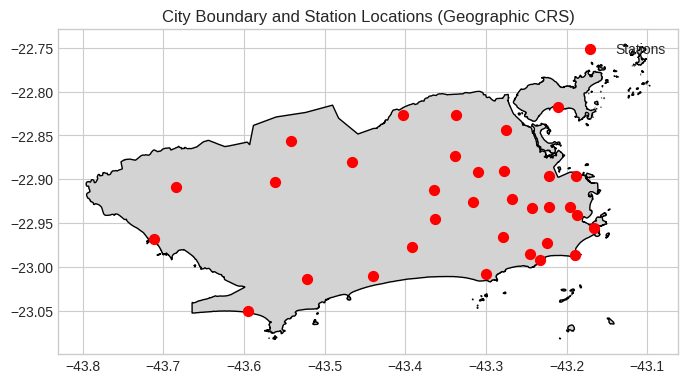

In [8]:
print("\nCity Boundary GeoDataFrame:")
display(city_boundary_gdf.head())
print(f"CRS of city boundary: {city_boundary_gdf.crs}")

# Plot to verify (optional)
fig, ax = plt.subplots(1,1, figsize=(8,8))
city_boundary_gdf.plot(ax=ax, facecolor='lightgray', edgecolor='black')
stations_gdf.plot(ax=ax, color='red', markersize=50, label='Stations')
plt.title("City Boundary and Station Locations (Geographic CRS)")
plt.legend()
plt.show()

### 3.4. Processing `ocorrencias`

In [9]:
# Convert datetime data type fields
ocorrencias['data_inicio'] = pd.to_datetime(ocorrencias['data_inicio'])
ocorrencias['data_fim'] = pd.to_datetime(ocorrencias['data_fim'])

# Map event type
ocorrencias['tipo'] = ocorrencias['id_pop'].map(pops.set_index('id')['titulo'])

# Filter ocorrences by type
ocorrencias = ocorrencias[ocorrencias['tipo'].isin(["Bolsão d'água em via", 'Alagamento', 'Enchente', 'Alagamentos e enchentes'])]

print("\nOcorrencias DataFrame (first 5 rows):")
display(ocorrencias.head())

# Convert to GeoDataFrame
ocorrencias_gdf = gpd.GeoDataFrame(
    ocorrencias,
    geometry=gpd.points_from_xy(ocorrencias.longitude, ocorrencias.latitude),
    crs=CRS_GEOGRAPHIC
)


Ocorrencias DataFrame (first 5 rows):


,id_pop,id_evento,bairro,data_inicio,data_fim,prazo,descricao,gravidade,latitude,longitude,status,tipo,data_particao,prazo_num
622,5.0,66955,Caju,2021-10-15 22:11:46+00:00,2021-10-15 22:16:00+00:00,Curto,"Av. rio de janeiro, 675 - caju",Baixo,-22.891448,-43.214630,Fechado,Bolsão d'água em via,2021-10-15,NaN
623,5.0,67278,Lagoa,2021-10-24 16:34:17+00:00,2021-10-24 19:52:44+00:00,Curto,"Av. epitácio pessoa, alt. r. garcia d'avila- l...",Baixo,-22.980942,-43.208720,Fechado,Bolsão d'água em via,2021-10-24,NaN
624,5.0,67280,Lagoa,2021-10-24 16:45:02+00:00,2021-10-24 18:19:05+00:00,Curto,"Av. borges de medeiros, alt. r. batista da cos...",Baixo,-22.965323,-43.215881,Fechado,Bolsão d'água em via,2021-10-24,NaN
625,5.0,67279,Lagoa,2021-10-24 16:39:46+00:00,2021-10-24 17:50:16+00:00,Curto,"Viaduto saint hilaire, alt. alça de acesso av....",Baixo,-22.961056,-43.204173,Fechado,Bolsão d'água em via,2021-10-24,NaN
626,5.0,66613,Penha,2021-10-03 17:29:02+00:00,2021-10-03 18:15:23+00:00,Curto,Rua ibiapina - alt. r. monsenhor alves rocha -...,Baixo,-22.841611,-43.276258,Fechado,Bolsão d'água em via,2021-10-03,NaN


### Select Target Period for Precipitation Values  

In [10]:
min_time_ocorrencias = ocorrencias['data_inicio'].min()

alertario = alertario[alertario['timestamp'] > str(min_time_ocorrencias.year)]

print(f"Min. Time: {alertario['timestamp'].min()} | Max. Time: {alertario['timestamp'].max()}")

Min. Time: 2015-04-09 15:00:00 | Max. Time: 2024-03-27 10:45:00


### 3.5. CRS Transformation
Transform `stations_gdf` and `city_boundary_gdf` to the projected CRS for accurate geometric operations (area calculation, Voronoi).

In [11]:
print(f"\nOriginal CRS - Stations: {stations_gdf.crs}, Boundary: {city_boundary_gdf.crs}")

if stations_gdf.crs != CRS_PROJECTED:
    stations_gdf = stations_gdf.to_crs(CRS_PROJECTED)
    print(f"Stations GeoDataFrame reprojected to {CRS_PROJECTED}")

if city_boundary_gdf.crs != CRS_PROJECTED:
    city_boundary_gdf = city_boundary_gdf.to_crs(CRS_PROJECTED)
    print(f"City Boundary GeoDataFrame reprojected to {CRS_PROJECTED}")

print(f"New CRS - Stations: {stations_gdf.crs}, Boundary: {city_boundary_gdf.crs}")

# Get the unary union of the city boundary in case it's a MultiPolygon or has multiple features
# This ensures a single, clean boundary polygon for clipping.
study_area_polygon = city_boundary_gdf.geometry.unary_union
print(f"Study area polygon type: {type(study_area_polygon)}")


Original CRS - Stations: EPSG:4326, Boundary: EPSG:4326
Stations GeoDataFrame reprojected to EPSG:31983
City Boundary GeoDataFrame reprojected to EPSG:31983
New CRS - Stations: EPSG:31983, Boundary: EPSG:31983
Study area polygon type: <class 'shapely.geometry.multipolygon.MultiPolygon'>


/tmp/ipykernel_2409188/1254141812.py:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_area_polygon = city_boundary_gdf.geometry.unary_union


## 7. Reload

### 7.1 Reload Results

In [12]:
# Reload Thiessen polygons
thiessen_path = os.path.join(OUTPUT_DATA_DIRECTORY, THIESSEN_POLYGONS_FILENAME)
if os.path.exists(thiessen_path):
    thiessen_polygons_gdf = gpd.read_file(thiessen_path)
    print(f"✓ Thiessen polygons loaded: {len(thiessen_polygons_gdf)} polygons")
else:
    print("⚠ Thiessen polygons file not found")
    
# Reload areal rainfall time series
areal_rainfall_path = os.path.join(OUTPUT_DATA_DIRECTORY, AREAL_RAINFALL_FILENAME)
if os.path.exists(areal_rainfall_path):
    areal_rainfall_ts_df = pd.read_csv(areal_rainfall_path, parse_dates=['timestamp'])
    print(f"✓ Areal rainfall time series loaded: {len(areal_rainfall_ts_df)} records")
else:
    print("⚠ Areal rainfall time series file not found")
    

✓ Thiessen polygons loaded: 33 polygons
✓ Areal rainfall time series loaded: 326448 records


---

# 14. Análise de Limiar de Intensidade-Duração por Estação

Esta seção implementa a etapa final da análise: a definição de limiares de chuva críticos para o acionamento de alagamentos. A nova abordagem, no entanto, não definirá uma única linha, mas **duas curvas de limiar** para criar três zonas distintas:

1.  **Zona Segura:** Abaixo do limiar inferior, onde a ocorrência de alagamentos é muito improvável.
2.  **Zona Crítica:** Acima do limiar superior, onde a ocorrência de alagamentos é muito provável.
3.  **Zona Mista (ou de Incerteza):** Entre os dois limiares, representando uma região de transição onde fatores secundários podem determinar a ocorrência de um alagamento.

Para encontrar essas duas linhas, implementaremos e compararemos duas metodologias distintas, conforme solicitado.

**Avaliação da Estratégia de Segmentação de Eventos:**

Conforme a avaliação anterior, a segmentação de eventos de chuva para a cidade inteira **não é suficiente**. O artigo exige uma análise local. Portanto, mantemos a decisão de segmentar os eventos de chuva para cada uma das 33 estações pluviométricas de forma independente, utilizando o método de **Identificação de Período Contínuo de Chuva (Opção 3)**, que é o mais adequado para capturar a Duração e a Intensidade de sistemas de chuva individuais.

**Plano de Implementação:**

1.  **Segmentação de Eventos de Chuva por Estação:** Identificar eventos de chuva discretos e calcular seus atributos (Duração e Intensidade Máxima) para cada estação.
2.  **Associação Espaço-Temporal e Classificação:** Vincular cada registro de alagamento a uma estação de influência e classificar os eventos de chuva como "Com Alagamento" (EA) ou "Sem Alagamento" (ESA).
3.  **Modelagem e Otimização dos Limiares:** Para cada estação, encontrar as duas curvas de limiar (`I = a * D^-b`) usando duas abordagens diferentes:
    *   **Abordagem A:** Grid Search com Métrica de Otimização.
    *   **Abordagem B:** Máquinas de Vetores de Suporte (SVM).
4.  **Visualização e Análise dos Resultados:** Gerar gráficos comparativos e consolidar os parâmetros de limiar (`a_inf`, `b_inf`, `a_sup`, `b_sup`) para análise.

---

## 15. Etapa 1: Segmentação de Eventos de Chuva por Estação

Nesta etapa, processaremos a série temporal de chuvas de 15 minutos para cada estação, a fim de identificar eventos discretos e calcular suas características principais.

In [13]:
# Importando bibliotecas necessárias para esta etapa
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Configurações de estilo para gráficos acadêmicos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

### 15.1. Cálculo dos Pontos I-D por Evento

In [14]:
def calcular_pontos_id_evento(event_slice: pd.Series, durations_min: list) -> list:
    """
    Calcula os pontos (D, I) para um único evento de chuva usando o método de janelas deslizantes.

    Args:
        event_slice (pd.Series): Série temporal com a chuva acumulada a cada 15 min para um evento.
        durations_min (list): Lista de durações em minutos a serem analisadas (ex: [15, 30, 60]).

    Returns:
        list: Lista de dicionários, cada um contendo um par 'duracao_h' e 'intensidade_mm_h'.
    """
    id_points = []
    
    for duration in durations_min:
        # Calcula o tamanho da janela em número de intervalos de 15 min
        window_size = int(duration / 15)
        
        if window_size < 1 or window_size > len(event_slice):
            continue # Pula durações menores que a resolução ou maiores que o próprio evento

        # Calcula a soma deslizante da precipitação
        rolling_sum = event_slice.rolling(window=window_size).sum()
        
        # Encontra a precipitação máxima acumulada para essa duração
        max_precip_for_duration = rolling_sum.max()
        
        # Converte a precipitação acumulada em intensidade média (mm/h)
        # Intensidade = (Chuva Total na Janela) / (Duração da Janela em horas)
        duration_h = duration / 60.0
        max_intensity = max_precip_for_duration / duration_h
        
        id_points.append({
            'duracao_h': duration_h,
            'intensidade_mm_h': max_intensity
        })
        
    return id_points

### 15.2. Função de Segmentação Atualizada

In [15]:
def segmenta_e_calcula_id(
    df_estacao: pd.DataFrame,
    id_estacao: int,
    min_rain: float = 0.1,
    min_dry_period_hours: int = 6,
    durations_to_analyze_min = [15, 30, 60, 120, 180, 720, 1440]
) -> pd.DataFrame:
    """
    Identifica eventos de chuva e, para cada um, calcula os múltiplos pontos I-D.
    Mantém a lógica original de segmentação de eventos, que estava correta.
    """
    if df_estacao.empty or 'acumulado_chuva_15_min' not in df_estacao.columns:
        return pd.DataFrame()

    df = df_estacao.sort_index()
    df['is_raining'] = df['acumulado_chuva_15_min'] >= min_rain
    rainy_periods = df[df['is_raining']]

    if rainy_periods.empty:
        return pd.DataFrame()

    time_diffs = rainy_periods.index.to_series().diff()
    min_dry_period = pd.Timedelta(hours=min_dry_period_hours)
    is_new_event_series = time_diffs > min_dry_period
    event_ids = is_new_event_series.cumsum()
    rainy_periods_with_id = rainy_periods.assign(event_id=event_ids)

    all_event_points = []
    
    for event_id, event_group in rainy_periods_with_id.groupby('event_id'):
        start_time = event_group.index.min()
        end_time = event_group.index.max()
        
        # Pega a série temporal completa do evento (incluindo zeros internos)
        event_slice = df.loc[start_time:end_time, 'acumulado_chuva_15_min']
        
        # Calcula os pontos I-D para este evento
        id_points = calcular_pontos_id_evento(event_slice, durations_to_analyze_min)
        
        # Adiciona informações do evento a cada ponto I-D gerado
        for point in id_points:
            point['id_estacao'] = id_estacao
            point['id_evento_chuva'] = f"{id_estacao}_{int(start_time.timestamp())}" # ID único para o evento original
            point['start_time'] = start_time
            point['end_time'] = end_time + pd.Timedelta(minutes=15)
            all_event_points.append(point)

    return pd.DataFrame(all_event_points)

### 15.3. Execução da Nova Segmentação em Lote

In [16]:
# Main Parameters
min_dry_period_hours = 1 # hour
min_rain = 1 # mm
# Durações de análise (em minutos), conforme o paper.
# Adaptamos 10 min para 15 min (0.25h) para se alinhar à resolução dos dados.
durations_to_analyze_min = [15, 30, 60, 120, 180, 720] # 1440 (24hs) excluded

# ---

# Garante que o timestamp é do tipo datetime e define como índice para eficiência
if not pd.api.types.is_datetime64_any_dtype(alertario['timestamp']):
    alertario['timestamp'] = pd.to_datetime(alertario['timestamp'])
alertario_indexed = alertario.set_index('timestamp')

# Obtém a lista de estações únicas com dados de chuva
station_ids = alertario['id_estacao'].unique()

# Lista para armazenar os DataFrames de pontos I-D de cada estação
lista_pontos_id = []

print(f"Iniciando a nova análise I-D para {len(station_ids)} estações...")
for station_id in tqdm(station_ids, desc="Processando Estações"):
    df_station_data = alertario_indexed[alertario_indexed['id_estacao'] == station_id]
    
    # Chama a nova função de segmentação e cálculo I-D
    station_id_points = segmenta_e_calcula_id(
        df_station_data,
        station_id,
        min_rain,
        min_dry_period_hours,
        durations_to_analyze_min
    )
    
    if not station_id_points.empty:
        lista_pontos_id.append(station_id_points)

# Concatena todos os resultados em um único DataFrame
# O novo DataFrame contém múltiplos pontos (D,I) para cada evento de chuva original
pontos_id_df = pd.concat(lista_pontos_id, ignore_index=True)

# Renomeia a coluna de intensidade para manter compatibilidade com o código subsequente
pontos_id_df = pontos_id_df.rename(columns={'intensidade_mm_h': 'intensidade_max_mm_h'})

print("\nAnálise I-D concluída.")
print(f"Total de pontos (D, I) gerados: {len(pontos_id_df)}")
print(f"Total de eventos de chuva originais identificados: {pontos_id_df['id_evento_chuva'].nunique()}")

Iniciando a nova análise I-D para 33 estações...


Processando Estações:   0%|          | 0/33 [00:00<?, ?it/s]


Análise I-D concluída.
Total de pontos (D, I) gerados: 63775
Total de eventos de chuva originais identificados: 29946


### 15.4. Visualização do Cálculo I-D


Amostra dos Pontos I-D Gerados:


,duracao_h,intensidade_max_mm_h,id_estacao,id_evento_chuva,start_time,end_time
0,0.25,4.0,22,22_1429238700,2015-04-17 02:45:00,2015-04-17 03:00:00
1,0.25,4.8,22,22_1429660800,2015-04-22 00:00:00,2015-04-22 00:45:00
2,0.50,4.8,22,22_1429660800,2015-04-22 00:00:00,2015-04-22 00:45:00
3,0.25,4.8,22,22_1429717500,2015-04-22 15:45:00,2015-04-22 16:15:00
4,0.50,4.4,22,22_1429717500,2015-04-22 15:45:00,2015-04-22 16:15:00



Estatísticas Descritivas dos Pontos I-D:


,duracao_h,intensidade_max_mm_h
count,63775.00,63775.00
mean,0.63,14.03
std,0.68,21.05
min,0.25,1.20
25%,0.25,5.60
50%,0.50,8.40
75%,0.50,16.40
max,12.00,2353.60



Visualização Rápida dos Pontos I-D Gerados (Estação 21):


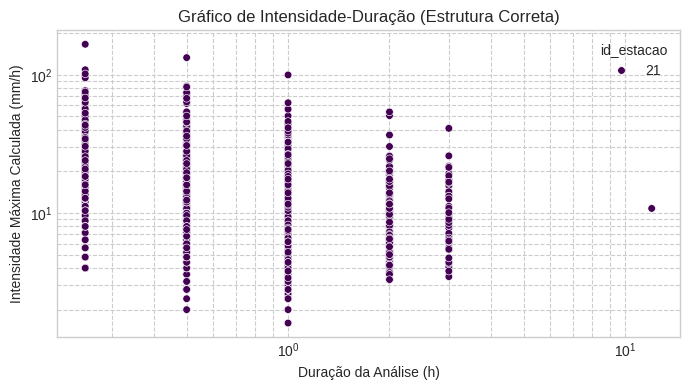

In [17]:
# Exibe as primeiras linhas do DataFrame resultante com formatação
print("\nAmostra dos Pontos I-D Gerados:")
display(pontos_id_df.head())

# Exibe estatísticas descritivas formatadas
print("\nEstatísticas Descritivas dos Pontos I-D:")
display(pontos_id_df[['duracao_h', 'intensidade_max_mm_h']].describe().style.format("{:.2f}"))

# Visualização inicial para verificar a estrutura dos dados
print("\nVisualização Rápida dos Pontos I-D Gerados (Estação 21):")
df_plot = pontos_id_df[pontos_id_df['id_estacao'] == 21]
if not df_plot.empty:
    plt.figure(figsize=(7, 4))
    sns.scatterplot(data=df_plot, x='duracao_h', y='intensidade_max_mm_h', hue='id_estacao', palette='viridis', s=30)
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Gráfico de Intensidade-Duração (Estrutura Correta)')
    plt.xlabel('Duração da Análise (h)')
    plt.ylabel('Intensidade Máxima Calculada (mm/h)')
    plt.grid(True, which="both", ls="--")
    # plt.legend(title='ID do Evento Original', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Não há dados para plotar para a estação 21.")

### 15.4. Visualização das Características dos Eventos

Para entender melhor a natureza dos eventos de chuva identificados, visualizamos a distribuição de suas durações e intensidades máximas.

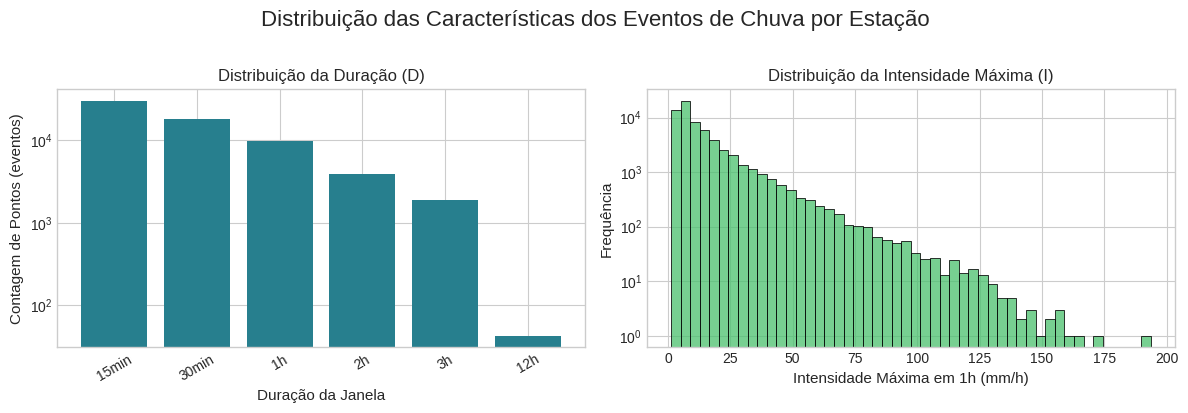

In [19]:
if not pontos_id_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Distribuição das Características dos Eventos de Chuva por Estação', fontsize=16, y=1.02)

    # Gráfico 1: Distribuição da Duração dos Eventos (barras, valores discretos)
    durations_h = [d / 60.0 for d in durations_to_analyze_min]  # converter minutos -> horas
    duration_labels = [f"{int(d*60)}min" if d < 1 else f"{int(d)}h" for d in durations_h]

    counts = [len(pontos_id_df[pontos_id_df['duracao_h'] == d]) for d in durations_h]

    axes[0].bar(duration_labels, counts, color=sns.color_palette("viridis")[2])
    axes[0].set_title('Distribuição da Duração (D)', fontsize=12)
    axes[0].set_xlabel('Duração da Janela', fontsize=11)
    axes[0].set_ylabel('Contagem de Pontos (eventos)', fontsize=11)
    axes[0].set_yscale('log')  # mantém escala log para a cauda longa
    axes[0].tick_params(axis='x', rotation=30)

    # Gráfico 2: Distribuição da Intensidade Máxima dos Eventos
    filtered_pontos_id_df = pontos_id_df[pontos_id_df['intensidade_max_mm_h'] < 500]
    sns.histplot(data=filtered_pontos_id_df, x='intensidade_max_mm_h', bins=50, ax=axes[1], color=sns.color_palette("viridis")[4])
    axes[1].set_title('Distribuição da Intensidade Máxima (I)', fontsize=12)
    axes[1].set_xlabel('Intensidade Máxima em 1h (mm/h)', fontsize=11)
    axes[1].set_ylabel('Frequência', fontsize=11)
    axes[1].set_yscale('log')

    plt.tight_layout()
    plt.show()
else:
    print("Nenhum evento de chuva foi identificado para gerar os gráficos de distribuição.")


## 16. Etapa 2: Associação Espaço-Temporal e Classificação dos Eventos

Com os eventos de chuva por estação definidos na etapa anterior, o próximo passo é associá-los aos registros de alagamento para classificá-los. Este processo é fundamental para determinar quais eventos de chuva estão correlacionados com impactos observados no solo.

### 16.1. Associação Espacial dos Alagamentos

Primeiro, atribuímos cada ocorrência de alagamento à sua estação pluviométrica de influência, utilizando os Polígonos de Thiessen gerados anteriormente.

In [20]:
import geopandas as gpd
import pandas as pd
from IPython.display import display

# Garante que os GeoDataFrames estão no mesmo sistema de coordenadas projetado para o join espacial
if 'CRS_PROJECTED' not in locals():
    CRS_PROJECTED = "EPSG:31983" # SIRGAS 2000 / UTM zone 23S

if ocorrencias_gdf.crs != CRS_PROJECTED:
    ocorrencias_gdf = ocorrencias_gdf.to_crs(CRS_PROJECTED)
if thiessen_polygons_gdf.crs != CRS_PROJECTED:
    thiessen_polygons_gdf = thiessen_polygons_gdf.to_crs(CRS_PROJECTED)

# Realiza o join espacial para associar cada alagamento ao seu polígono e, consequentemente, à sua estação
# Usamos 'inner' para manter apenas os alagamentos que caem dentro de uma área de influência
floods_with_station_gdf = gpd.sjoin(
    ocorrencias_gdf,
    thiessen_polygons_gdf[['id_estacao', 'geometry']],
    how='inner',
    predicate='within'
)

# Seleciona e renomeia colunas para clareza
floods_with_station_gdf = floods_with_station_gdf[['id_evento', 'data_inicio', 'id_estacao', 'geometry']].reset_index(drop=True)

print(f"Total de {len(floods_with_station_gdf)} ocorrências de alagamento associadas a uma estação pluviométrica.")
print("\nAmostra de Alagamentos com Estação de Influência Atribuída:")
display(floods_with_station_gdf.head())

Total de 4349 ocorrências de alagamento associadas a uma estação pluviométrica.

Amostra de Alagamentos com Estação de Influência Atribuída:


,id_evento,data_inicio,id_estacao,geometry
0,66955,2021-10-15 22:11:46+00:00,24,POINT (683134.286 7467386.639)
1,67278,2021-10-24 16:34:17+00:00,29,POINT (683619.839 7457469.011)
2,67280,2021-10-24 16:45:02+00:00,29,POINT (682906.571 7459207.57)
3,67279,2021-10-24 16:39:46+00:00,29,POINT (684112.951 7459665.478)
4,66613,2021-10-03 17:29:02+00:00,21,POINT (676875.919 7472980.684)


### 16.2. Classificação dos Eventos de Chuva (EA vs. ESA)

Agora, usamos a associação temporal para classificar cada evento de chuva em `pontos_id_df` como "Com Alagamento" (EA) ou "Sem Alagamento" (ESA). Um evento de chuva é classificado como EA se o seu período de ocorrência coincidiu com pelo menos um registro de alagamento em sua área de influência.

In [22]:
# --- MODIFICAÇÃO: Usa min_flood_records ---
min_flood_records = 2  # Defina este valor conforme necessário antes de rodar o código


# ---

print("Iniciando a classificação dos eventos de chuva...")

# 1. Criar DataFrame de eventos de chuva únicos para a classificação
eventos_unicos_df = pontos_id_df.drop_duplicates(subset=['id_evento_chuva']).copy()
eventos_unicos_df = eventos_unicos_df[['id_evento_chuva', 'id_estacao', 'start_time', 'end_time']]

# 2. Preparar os dados e classificar os eventos únicos
floods_to_check = floods_with_station_gdf[['data_inicio', 'id_estacao']]

eventos_unicos_df['id_estacao'] = eventos_unicos_df['id_estacao'].astype(str)
floods_to_check['id_estacao'] = floods_to_check['id_estacao'].astype(str)

for df in [eventos_unicos_df, floods_to_check]:
    for col in ['start_time', 'end_time', 'data_inicio']:
        if col in df.columns:
            if df[col].dt.tz is None:
                df[col] = df[col].dt.tz_localize('UTC')
            else:
                df[col] = df[col].dt.tz_convert('UTC')

# Merge para criar pares de evento de chuva e alagamento que ocorreram na mesma área de estação
merged_pairs = pd.merge(eventos_unicos_df, floods_to_check, on='id_estacao')

# Filtra para encontrar os pares onde há sobreposição temporal
temporal_overlap_condition = (
    (merged_pairs['data_inicio'] >= merged_pairs['start_time']) &
    (merged_pairs['data_inicio'] < merged_pairs['end_time'])
)
eventos_com_alagamento = merged_pairs[temporal_overlap_condition]

# Conta o número de registros de alagamento por evento de chuva
flood_counts = eventos_com_alagamento.groupby('id_evento_chuva').size()

# Obtém a lista de IDs de eventos de chuva que têm pelo menos min_flood_records
ids_eventos_ea = flood_counts[flood_counts >= min_flood_records].index.unique()

# 3. Propagar a classificação para o DataFrame principal de pontos I-D
pontos_id_df['classificacao'] = 'ESA'
pontos_id_df.loc[pontos_id_df['id_evento_chuva'].isin(ids_eventos_ea), 'classificacao'] = 'EA'


# --- SAÍDAS E VERIFICAÇÕES (Mantendo o Padrão do Código Original) ---

print("Classificação dos eventos de chuva concluída.")

# Resumo global da classificação dos pontos I-D
classification_counts = pontos_id_df['classificacao'].value_counts()
print("\nResumo da Classificação Global dos Pontos I-D:")
print(f"Pontos Sem Alagamento (ESA): {classification_counts.get('ESA', 0)}")
print(f"Pontos Com Alagamento (EA):  {classification_counts.get('EA', 0)}")

# Amostra do DataFrame final com a nova coluna 'classificacao'
print("\nAmostra do DataFrame 'pontos_id_df' com a classificação:")
display(pontos_id_df.sample(5))

# Resumo da classificação por estação, contando *eventos únicos*
# É crucial usar drop_duplicates aqui para contar eventos, não pontos I-D.
eventos_classificados_df = pontos_id_df.drop_duplicates(subset=['id_evento_chuva'])
classification_summary = eventos_classificados_df.groupby('id_estacao')['classificacao'].value_counts().unstack(fill_value=0)
classification_summary['Total'] = classification_summary.sum(axis=1)
# classification_summary = classification_summary.sort_values(by='EA', ascending=False)

print("\nResumo da Classificação de EVENTOS por Estação:")
display(classification_summary.T.style.format("{:d}")) #.background_gradient(cmap='viridis', subset=['EA', 'ESA'], axis=0)

# A visualização do gráfico de barras (código 16.3) pode agora ser executada
# usando o `classification_summary` que acabamos de criar, e funcionará como esperado.

Iniciando a classificação dos eventos de chuva...


/tmp/ipykernel_2409188/2624888676.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  floods_to_check['id_estacao'] = floods_to_check['id_estacao'].astype(str)
/tmp/ipykernel_2409188/2624888676.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].dt.tz_convert('UTC')


Classificação dos eventos de chuva concluída.

Resumo da Classificação Global dos Pontos I-D:
Pontos Sem Alagamento (ESA): 62831
Pontos Com Alagamento (EA):  944

Amostra do DataFrame 'pontos_id_df' com a classificação:


,duracao_h,intensidade_max_mm_h,id_estacao,id_evento_chuva,start_time,end_time,classificacao
1340,0.50,26.4,22,22_1640880000,2021-12-30 16:00:00,2021-12-30 17:30:00,ESA
6577,0.50,14.4,25,25_1566328500,2019-08-20 19:15:00,2019-08-20 20:30:00,ESA
22315,0.25,20.8,26,26_1431058500,2015-05-08 04:15:00,2015-05-08 05:00:00,ESA
43723,2.00,11.4,5,5_1598030100,2020-08-21 17:15:00,2020-08-21 23:30:00,ESA
45996,0.50,41.6,3,3_1582315200,2020-02-21 20:00:00,2020-02-21 21:30:00,ESA



Resumo da Classificação de EVENTOS por Estação:


id_estacao,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33
classificacao,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
EA,0,0,2,3,3,1,11,0,2,6,14,6,9,1,5,9,1,14,2,0,13,6,7,19,4,0,5,22,15,0,24,39,1
ESA,970,882,1151,989,944,812,859,784,728,812,811,797,765,836,784,1083,1047,815,983,832,925,856,810,870,1078,795,804,1342,833,991,935,759,1020
Total,970,882,1153,992,947,813,870,784,730,818,825,803,774,837,789,1092,1048,829,985,832,938,862,817,889,1082,795,809,1364,848,991,959,798,1021


### 16.3. Visualização da Classificação

Um gráfico de barras empilhadas é uma forma eficaz de visualizar a proporção de eventos com e sem alagamento para cada estação, permitindo uma rápida comparação da criticidade entre as diferentes áreas de influência.

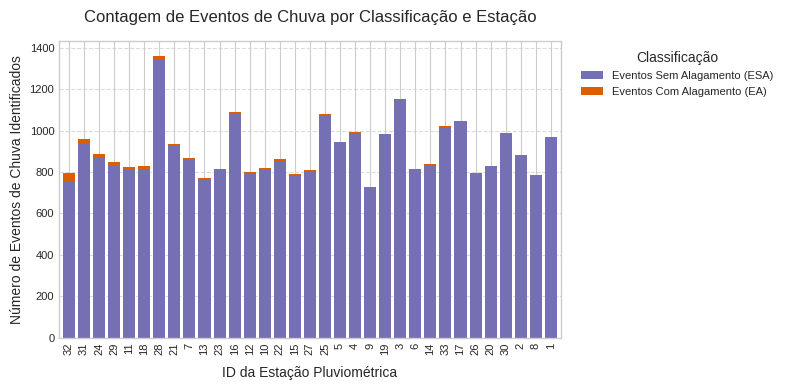

In [23]:
# Prepara os dados para o gráfico de barras empilhadas
summary_for_plot = classification_summary[['EA', 'ESA']].copy()
summary_for_plot['EA_perc'] = (summary_for_plot['EA'] / (summary_for_plot['EA'] + summary_for_plot['ESA'])) * 100
summary_for_plot = summary_for_plot.sort_values(by='EA_perc', ascending=False)

# Criação do gráfico
fig, ax = plt.subplots(figsize=(8, 4))

# Cores para as barras
colors = {'EA': '#d95f02', 'ESA': '#7570b3'}

# Plot das barras empilhadas
summary_for_plot[['ESA', 'EA']].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[colors['ESA'], colors['EA']],
    width=0.8
)

# Configuração de títulos e rótulos
ax.set_title('Contagem de Eventos de Chuva por Classificação e Estação', fontsize=12, pad=14)
ax.set_xlabel('ID da Estação Pluviométrica', fontsize=10, labelpad=8)
ax.set_ylabel('Número de Eventos de Chuva Identificados', fontsize=10)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.tick_params(axis='y', labelsize=8)

# Legenda
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ['Eventos Sem Alagamento (ESA)', 'Eventos Com Alagamento (EA)'],
    title='Classificação',
    fontsize=8,
    title_fontsize=10,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

# Adiciona uma grade horizontal para melhor leitura
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()






#### Gráfico I-D por Estação

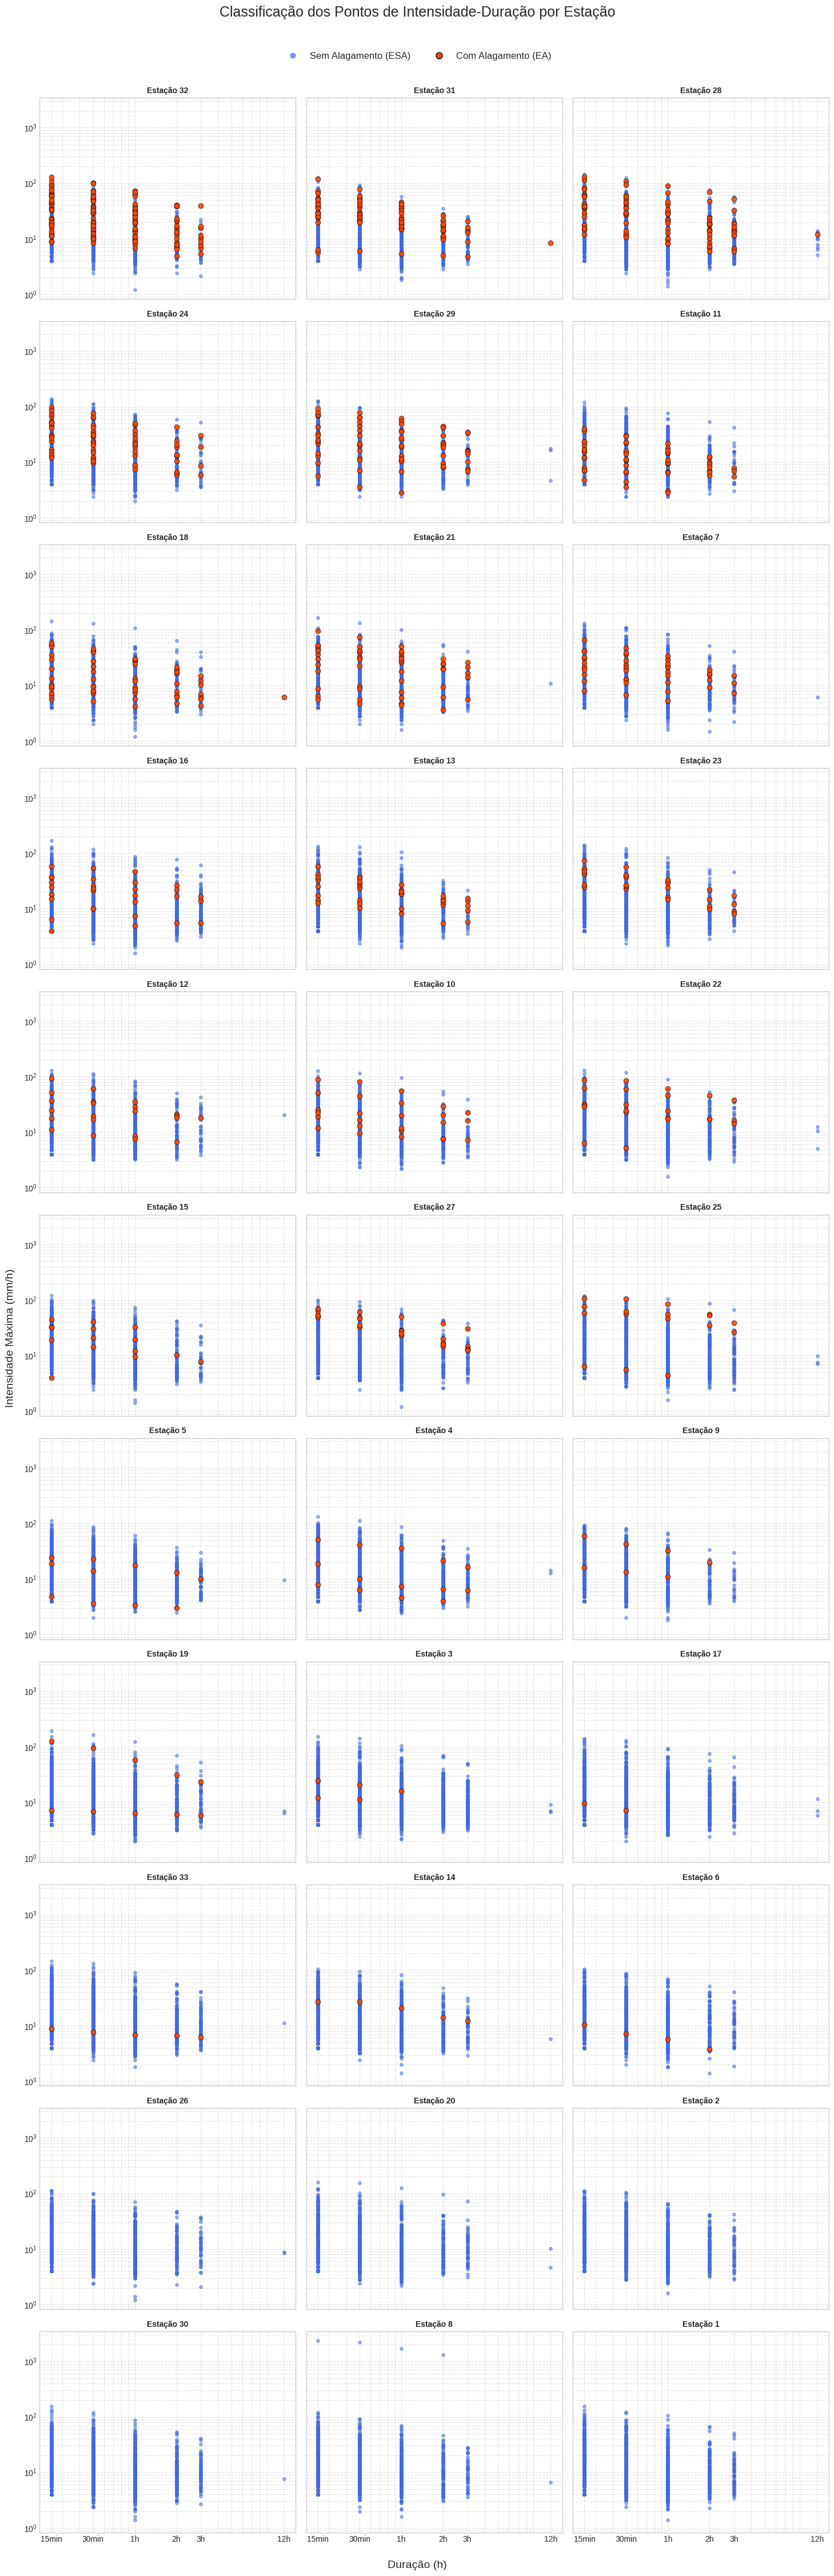

In [59]:
max_stations = None # use None para todas as estações

# 1. Obter a lista de estações para plotar
station_ids_to_plot = classification_summary.sort_values(by='EA', ascending=False).index.astype(int)

# 2. Configurar a grade de subplots
n_stations = len(station_ids_to_plot)
if max_stations is None:
    max_stations = n_stations

n_cols = 3
n_rows = int(np.ceil(max_stations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()  # Facilita a iteração

# Cores, tamanhos e ordem de plotagem para a visualização
colors = {'ESA': 'royalblue', 'EA': 'orangered'}
zorders = {'ESA': 1, 'EA': 2}
sizes = {'ESA': 15, 'EA': 40}

# 3. Iterar e plotar para cada estação
for i, station_id in enumerate(station_ids_to_plot[:max_stations]):
    ax = axes[i]
    station_data = pontos_id_df[pontos_id_df['id_estacao'] == station_id]

    # Plotar ESA (Sem Alagamento) primeiro, no fundo
    esa_data = station_data[station_data['classificacao'] == 'ESA']
    ax.scatter(esa_data['duracao_h'], esa_data['intensidade_max_mm_h'],
               color=colors['ESA'], s=sizes['ESA'], alpha=0.5, zorder=zorders['ESA'], label='ESA')

    # Plotar EA (Com Alagamento) por cima, para destaque
    ea_data = station_data[station_data['classificacao'] == 'EA']
    ax.scatter(ea_data['duracao_h'], ea_data['intensidade_max_mm_h'],
               color=colors['EA'], s=sizes['EA'], alpha=0.9, zorder=zorders['EA'], label='EA',
               edgecolor='black', linewidth=0.5)

    # Configurações do subplot
    ax.set_title(f"Estação {station_id}", fontsize=10, fontweight='bold')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.6)

    x_ticklabels = ['15min', '30min', '1h', '2h', '3h', '12h']
    ax.set_xticks([t/60 for t in durations_to_analyze_min])
    ax.set_xticklabels(x_ticklabels)

# 4. Desligar eixos dos subplots extras que não foram usados
for i in range(max_stations, len(axes)):
    axes[i].axis('off')

# 5. Adicionar legendas e títulos globais para a figura inteira
# Criar 'handles' personalizados para a legenda
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Sem Alagamento (ESA)',
               markerfacecolor=colors['ESA'], markersize=8, alpha=0.7),
    plt.Line2D([0], [0], marker='o', color='w', label='Com Alagamento (EA)',
               markerfacecolor=colors['EA'], markersize=8, markeredgecolor='black')
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.015), ncol=2, fontsize=12)

# Adicionar rótulos de eixos comuns para toda a grade
fig.supxlabel('Duração (h)', fontsize=14)
fig.supylabel('Intensidade Máxima (mm/h)', fontsize=14)

fig.suptitle('Classificação dos Pontos de Intensidade-Duração por Estação', fontsize=18, y=1.03)

plt.tight_layout(rect=[0.01, 0.01, 0.99, 1.01]) # Ajusta o layout para não sobrepor os títulos
plt.show()

## 17. Etapa 3: Modelagem e Definição das Zonas de Limiar

Nesta etapa, determinaremos as duas curvas de limiar (`I = a * D⁻ᵇ`) que definem as zonas segura, mista e crítica para cada estação pluviométrica. Implementaremos e compararemos duas abordagens distintas para encontrar os parâmetros `(a, b)` para as curvas de limiar inferior e superior.

In [80]:
# Importando bibliotecas para modelagem
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import warnings

# Suprimir avisos de convergência do SVM que podem poluir o output
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn')

### 17.1. Abordagem A: Grid Search com Métrica de Otimização

Esta abordagem testa sistematicamente uma grade de parâmetros `(a, b)` para encontrar as curvas que melhor satisfazem critérios pré-definidos para os limiares inferior e superior.

-   **Limiar Inferior:** Busca a curva mais alta possível que mantém a taxa de falsos positivos (eventos sem alagamento classificados incorretamente como críticos) abaixo de um percentual baixo (ex: 5%).
-   **Limiar Superior:** Busca a curva mais baixa possível que mantém a taxa de verdadeiros positivos (eventos com alagamento classificados corretamente) acima de um percentual alto (ex: 80%).

In [51]:
def encontrar_limiares_grid_search(df_eventos_estacao: pd.DataFrame,
                                    fpr_threshold: float = 0.05,
                                    tpr_threshold: float = 0.80,
                                    a_vals = np.linspace(5, 50, 100),
                                    b_vals = np.linspace(0.1, 1.5, 100)) -> dict:
    """
    Encontra os limiares inferior e superior usando uma busca em grade (grid search).

    Args:
        df_eventos_estacao (pd.DataFrame): Eventos de chuva para uma estação.
        fpr_threshold (float): Limiar máximo da Taxa de Falsos Positivos para a curva inferior.
        tpr_threshold (float): Limiar mínimo da Taxa de Verdadeiros Positivos para a curva superior.

    Returns:
        dict: Dicionário com os parâmetros 'a_inf_grid', 'b_inf_grid', 'a_sup_grid', 'b_sup_grid'.
    """
    eventos_ea = df_eventos_estacao[df_eventos_estacao['classificacao'] == 'EA']
    eventos_esa = df_eventos_estacao[df_eventos_estacao['classificacao'] == 'ESA']

    if eventos_ea.empty or eventos_esa.empty:
        return {'a_inf_grid': np.nan, 'b_inf_grid': np.nan, 'a_sup_grid': np.nan, 'b_sup_grid': np.nan}

    # Define a grade de busca para os parâmetros

    best_lower = {'a': np.nan, 'b': np.nan, 'score': -np.inf}
    best_upper = {'a': np.nan, 'b': np.nan, 'score': -np.inf}

    for a in a_vals:
        for b in b_vals:
            # Calcula o limiar para todos os eventos com o par (a, b) atual
            i_limiar_ea = a * (eventos_ea['duracao_h'] ** -b)
            i_limiar_esa = a * (eventos_esa['duracao_h'] ** -b)

            # Calcula métricas
            tp = (eventos_ea['intensidade_max_mm_h'] >= i_limiar_ea).sum()
            fp = (eventos_esa['intensidade_max_mm_h'] >= i_limiar_esa).sum()
            
            tpr = tp / len(eventos_ea)
            fpr = fp / len(eventos_esa)

            # Otimização para o limiar inferior (maximizar 'a' mantendo FPR baixo)
            if fpr <= fpr_threshold:
                if a > best_lower['score']:
                    best_lower = {'a': a, 'b': b, 'score': a}

            # Otimização para o limiar superior (minimizar 'a' mantendo TPR alto)
            if tpr >= tpr_threshold:
                # Usamos -a para que o score maior (-a menor) seja melhor
                if -a > best_upper['score']:
                    best_upper = {'a': a, 'b': b, 'score': -a}

    return {
        'a_inf_grid': best_lower['a'], 'b_inf_grid': best_lower['b'],
        'a_sup_grid': best_upper['a'], 'b_sup_grid': best_upper['b']
    }

### 17.2. Abordagem B: Máquinas de Vetores de Suporte (SVM)

Esta abordagem utiliza um classificador SVM linear no espaço logarítmico dos dados. As margens do hiperplano de separação encontrado pelo SVM são usadas para definir as curvas de limiar inferior e superior, oferecendo uma fronteira de decisão matematicamente robusta.

In [52]:
def encontrar_limiares_svm(df_eventos_estacao: pd.DataFrame) -> dict:
    """
    Encontra os limiares inferior e superior usando um classificador SVM.

    Args:
        df_eventos_estacao (pd.DataFrame): Eventos de chuva para uma estação.

    Returns:
        dict: Dicionário com os parâmetros 'a_inf_svm', 'b_inf_svm', 'a_sup_svm', 'b_sup_svm'.
    """
    # Filtra dados para evitar log(0) e garante que há ambas as classes
    df_filtered = df_eventos_estacao[
        (df_eventos_estacao['duracao_h'] > 0) & (df_eventos_estacao['intensidade_max_mm_h'] > 0)
    ]
    if df_filtered['classificacao'].nunique() < 2:
        return {'a_inf_svm': np.nan, 'b_inf_svm': np.nan, 'a_sup_svm': np.nan, 'b_sup_svm': np.nan}

    # Transforma os dados para o espaço logarítmico
    X = np.log(df_filtered[['duracao_h', 'intensidade_max_mm_h']].values)
    y = (df_filtered['classificacao'] == 'EA').astype(int).values

    # Cria e treina o pipeline SVM com normalização e pesos de classe balanceados
    svm_pipeline = make_pipeline(StandardScaler(), SVC(kernel='linear', class_weight='balanced'))
    svm_pipeline.fit(X, y)
    
    # Extrai o modelo treinado do pipeline
    svc_model = svm_pipeline.named_steps['svc']
    scaler = svm_pipeline.named_steps['standardscaler']
    
    # Coeficientes e intercepto do hiperplano no espaço escalado
    w = svc_model.coef_[0]
    intercept = svc_model.intercept_[0]
    
    # Desfaz a escala para obter os coeficientes no espaço logarítmico original
    w_original = w / scaler.scale_
    intercept_original = intercept - np.sum(w * scaler.mean_ / scaler.scale_)

    # Extrai os coeficientes para log(D) e log(I)
    w_d, w_i = w_original[0], w_original[1]

    if abs(w_i) < 1e-9: # Evita divisão por zero
        return {'a_inf_svm': np.nan, 'b_inf_svm': np.nan, 'a_sup_svm': np.nan, 'b_sup_svm': np.nan}

    # Calcula os parâmetros 'a' e 'b' para as três linhas (margens e decisão)
    # A equação é: log(I) = - (w_d/w_i) * log(D) - (intercept/w_i)
    # Comparando com log(I) = log(a) - b*log(D), temos:
    # b = w_d / w_i
    # a = exp(-intercept / w_i)
    
    b_svm = w_d / w_i
    
    # Interceptos para as margens inferior, de decisão e superior
    intercept_inf = (intercept_original - 1) / w_i
    intercept_sup = (intercept_original + 1) / w_i
    
    a_inf = np.exp(-intercept_sup)
    a_sup = np.exp(-intercept_inf)
    
    # Garante que a_sup > a_inf
    if a_inf > a_sup:
        a_inf, a_sup = a_sup, a_inf

    return {
        'a_inf_svm': a_inf, 'b_inf_svm': b_svm,
        'a_sup_svm': a_sup, 'b_sup_svm': b_svm
    }

### 17.3. Execução em Lote

Agora, aplicamos ambas as funções de modelagem a todas as estações que possuem um número mínimo de eventos com e sem alagamento, consolidando os resultados em uma única tabela para análise comparativa.

In [53]:
fpr_threshold = 0.05
tpr_threshold = 0.80
a_vals = np.linspace(5, 50, 100)
b_vals = np.linspace(0.1, 1.5, 100)

# Lista para armazenar os resultados de cada estação
resultados_lista = []
station_ids_com_dados = pontos_id_df['id_estacao'].unique()

print(f"Iniciando modelagem de limiares para {len(station_ids_com_dados)} estações...")
for station_id in tqdm(station_ids_com_dados, desc="Modelando Limiares"):
    df_station = pontos_id_df[pontos_id_df['id_estacao'] == station_id]
    
    # Verifica se há dados suficientes para a modelagem
    counts = df_station['classificacao'].value_counts()
    if 'EA' not in counts or 'ESA' not in counts or counts['EA'] < 5 or counts['ESA'] < 5:
        continue

    # Executa a Abordagem A: Grid Search
    params_grid = encontrar_limiares_grid_search(
        df_station,
        fpr_threshold,
        tpr_threshold,
        a_vals, b_vals
    )
    
    # Executa a Abordagem B: SVM
    params_svm = encontrar_limiares_svm(df_station)
    
    # Consolida os resultados
    resultado_final = {'id_estacao': station_id}
    resultado_final.update(params_grid)
    resultado_final.update(params_svm)
    resultados_lista.append(resultado_final)

# Cria o DataFrame final com os resultados consolidados
resultados_limiar_consolidado = pd.DataFrame(resultados_lista).set_index('id_estacao')

print("\nModelagem concluída.")
print("Tabela de Parâmetros de Limiar Consolidados (Grid Search vs. SVM):")

# Estiliza a tabela para publicação
styled_table = resultados_limiar_consolidado.style.format("{:.2f}", na_rep="-").set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]},
     {'selector': 'td', 'props': [('text-align', 'center')]}]
).set_caption("Parâmetros 'a' e 'b' para as curvas de limiar inferior (inf) e superior (sup) por método de modelagem.")

display(styled_table)


Iniciando modelagem de limiares para 33 estações...


Modelando Limiares:   0%|          | 0/33 [00:00<?, ?it/s]

/tmp/ipykernel_2341923/1978299652.py:56: RuntimeWarning: overflow encountered in exp
  a_inf = np.exp(-intercept_sup)



Modelagem concluída.
Tabela de Parâmetros de Limiar Consolidados (Grid Search vs. SVM):


,a_inf_grid,b_inf_grid,a_sup_grid,b_sup_grid,a_inf_svm,b_inf_svm,a_sup_svm,b_sup_svm
id_estacao,,,,,,,,
22,50.00,0.10,5.00,0.10,10.77,0.50,24.39,0.50
19,50.00,0.10,5.00,0.10,2.82,-1.11,33.62,-1.11
13,50.00,0.10,5.00,0.10,6.88,0.58,18.59,0.58
25,50.00,0.10,5.00,0.10,25.17,0.32,37.50,0.32
16,50.00,0.10,5.00,0.10,3.54,0.51,24.11,0.51
24,50.00,0.10,5.00,0.10,3.00,0.95,21.21,0.95
28,50.00,0.10,5.00,0.10,7.68,0.49,24.29,0.49
18,50.00,0.10,5.00,0.10,0.84,1.69,27.38,1.69
32,50.00,0.10,5.00,0.10,4.18,0.86,19.59,0.86


## 18. Etapa 4: Visualização e Análise dos Resultados

A etapa final consiste em visualizar os limiares encontrados por ambos os métodos para interpretar e comparar os resultados. Criaremos gráficos de Intensidade-Duração para estações individuais e mapas para analisar a distribuição espacial dos parâmetros de limiar.

### 18.1. Criação da Função de Plotagem Comparativa

Desenvolvemos uma função robusta para gerar o gráfico de Intensidade-Duração para uma única estação. Esta função plotará os eventos de chuva, coloridos por sua classificação, e sobreporá as duas curvas de limiar (inferior e superior) encontradas por ambos os métodos (Grid Search e SVM).

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plotar_grafico_limiar_comparativo(id_estacao: int, df_eventos: pd.DataFrame, df_resultados: pd.DataFrame, sample=1.0, random_state=None):
    """
    Gera um gráfico de Intensidade-Duração comparando os limiares dos métodos Grid Search e SVM.

    Args:
        id_estacao (int): O ID da estação a ser plotada.
        df_eventos (pd.DataFrame): DataFrame com todos os eventos de chuva de todas as estações.
        df_resultados (pd.DataFrame): DataFrame com os parâmetros de limiar consolidados.
    """
    # Filtra os dados para a estação específica
    df_station_events = df_eventos[df_eventos['id_estacao'] == id_estacao]
    if df_station_events.empty:
        print(f"Não há dados de eventos para a estação {id_estacao}.")
        return

    if sample and sample > 1:
        df_station_events = df_station_events.sample(sample, replace=False, random_state=random_state)
    elif sample and sample > 0:
        size = int(samples * len(df_station_events))
        df_station_events = df_station_events.sample(size, replace=False, random_state=random_state)
    
    params = df_resultados.loc[id_estacao]

    # Separa eventos com e sem alagamento
    eventos_ea = df_station_events[df_station_events['classificacao'] == 'EA']
    eventos_esa = df_station_events[df_station_events['classificacao'] == 'ESA']

    # Configuração do gráfico
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Cores e marcadores
    colors = {'EA': '#d95f02', 'ESA': '#7570b3'}
    
    # Plot dos pontos de evento
    ax.scatter(eventos_esa['duracao_h'], eventos_esa['intensidade_max_mm_h'],
               color=colors['ESA'], alpha=0.5, label='Evento Sem Alagamento (ESA)', s=50, edgecolor='k', linewidth=0.5)
    ax.scatter(eventos_ea['duracao_h'], eventos_ea['intensidade_max_mm_h'],
               color=colors['EA'], alpha=0.8, label='Evento Com Alagamento (EA)', s=80, marker='^', edgecolor='k', linewidth=0.5)

    # Gera pontos para as curvas de limiar
    d_range = np.logspace(np.log10(max(0.1, df_station_events['duracao_h'].min())),
                          np.log10(df_station_events['duracao_h'].max()), 100)

    # Plot das curvas do Grid Search
    if pd.notna(params['a_inf_grid']):
        i_inf_grid = params['a_inf_grid'] * (d_range ** -params['b_inf_grid'])
        ax.plot(d_range, i_inf_grid, color='blue', linestyle='--', linewidth=2, label='Grid Search - Limiar Inferior')
    if pd.notna(params['a_sup_grid']):
        i_sup_grid = params['a_sup_grid'] * (d_range ** -params['b_sup_grid'])
        ax.plot(d_range, i_sup_grid, color='blue', linestyle='-', linewidth=2.5, label='Grid Search - Limiar Superior')

    # Plot das curvas do SVM
    if pd.notna(params['a_inf_svm']):
        i_inf_svm = params['a_inf_svm'] * (d_range ** -params['b_inf_svm'])
        ax.plot(d_range, i_inf_svm, color='red', linestyle='--', linewidth=2, label='SVM - Limiar Inferior')
    if pd.notna(params['a_sup_svm']):
        i_sup_svm = params['a_sup_svm'] * (d_range ** -params['b_sup_svm'])
        ax.plot(d_range, i_sup_svm, color='red', linestyle='-', linewidth=2.5, label='SVM - Limiar Superior')

    # Configuração dos eixos e título
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'Limiares de Intensidade-Duração para a Estação {id_estacao}', fontsize=16, pad=20)
    ax.set_xlabel('Duração do Evento (D) [horas]', fontsize=12)
    ax.set_ylabel('Intensidade Máxima em 1h (I) [mm/h]', fontsize=12)
    ax.grid(True, which="both", linestyle='--', linewidth=0.5)
    
    # Limites dos eixos para melhor visualização
#     ax.set_xlim(left=0.1)
#     ax.set_ylim(bottom=1)

    # Legenda
    ax.legend(title='Legenda', fontsize=10, title_fontsize=11)
    
    plt.tight_layout()
    plt.show()

### 18.2. Geração e Análise dos Gráficos

Geramos os gráficos para algumas estações representativas para uma inspeção visual detalhada dos resultados. A seleção inclui estações com um número significativo de eventos com alagamento para garantir uma análise robusta.

Gerando gráficos de limiar para as 3 estações com mais eventos de alagamento registrados...


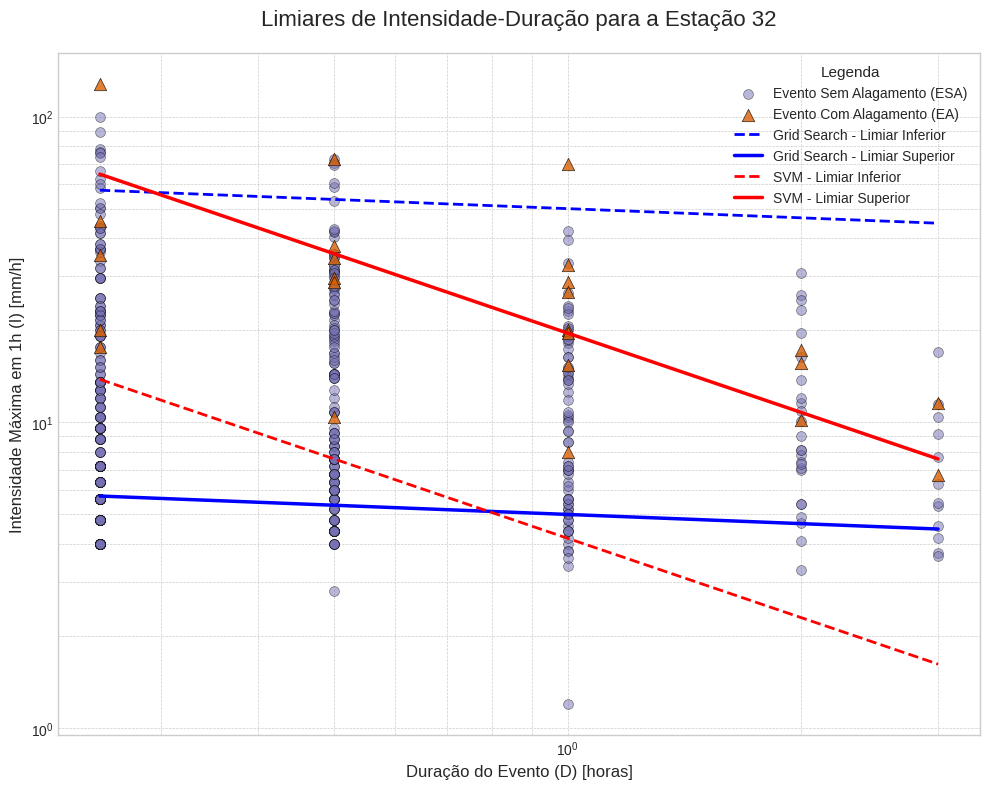

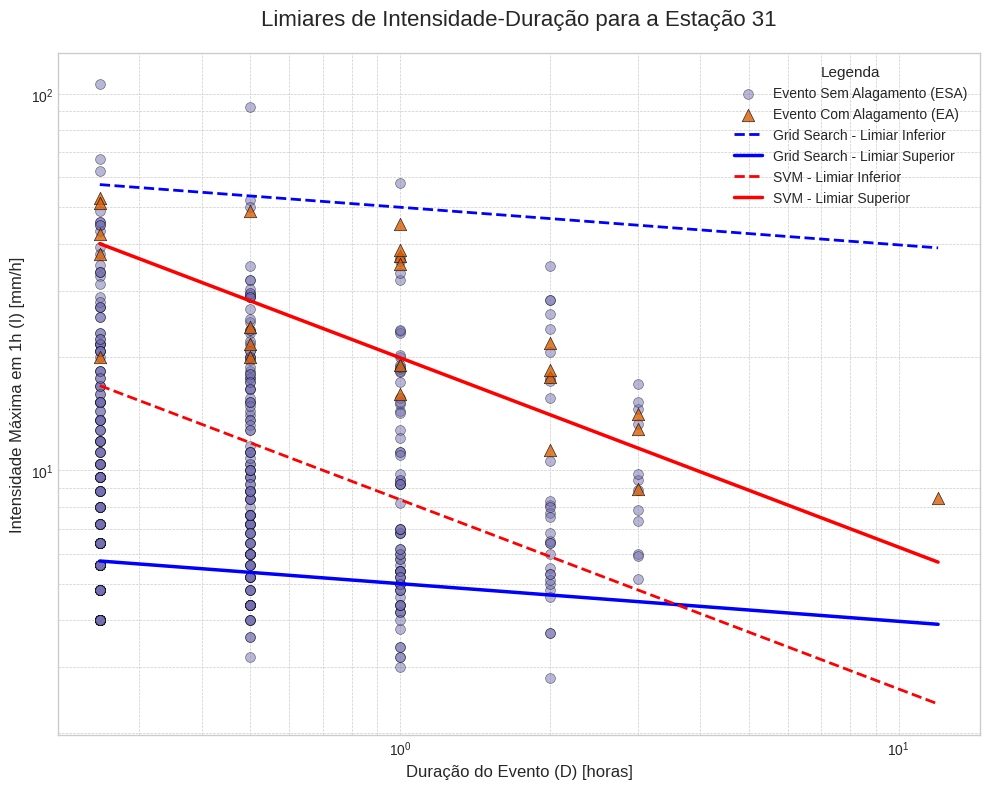

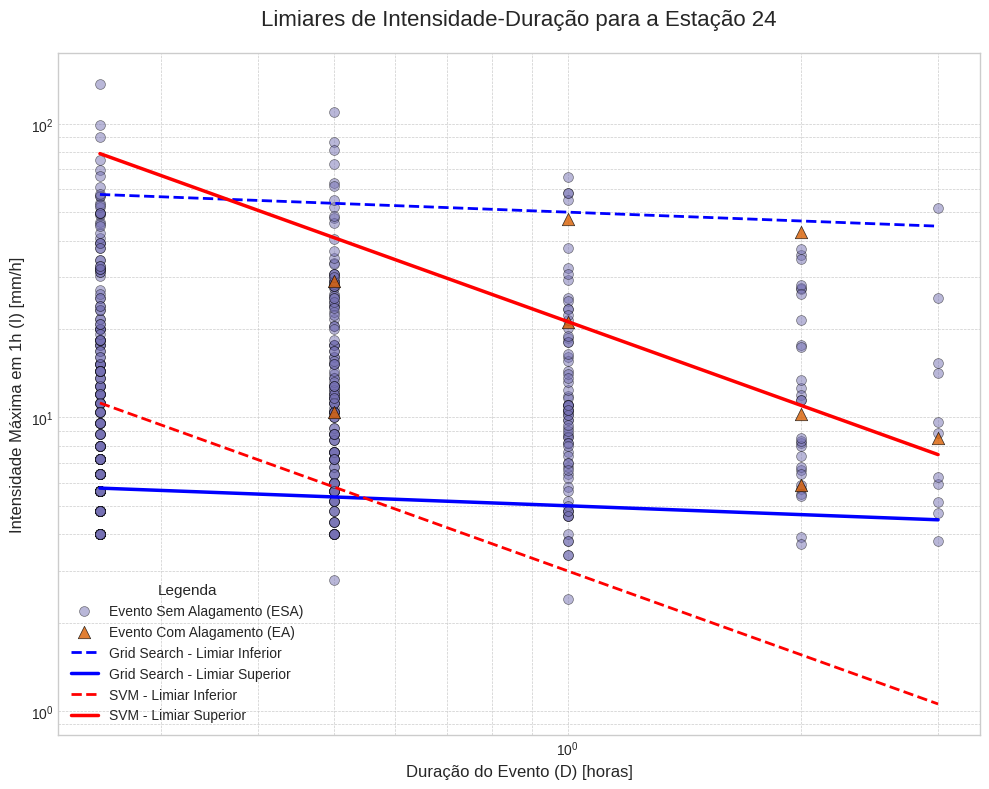

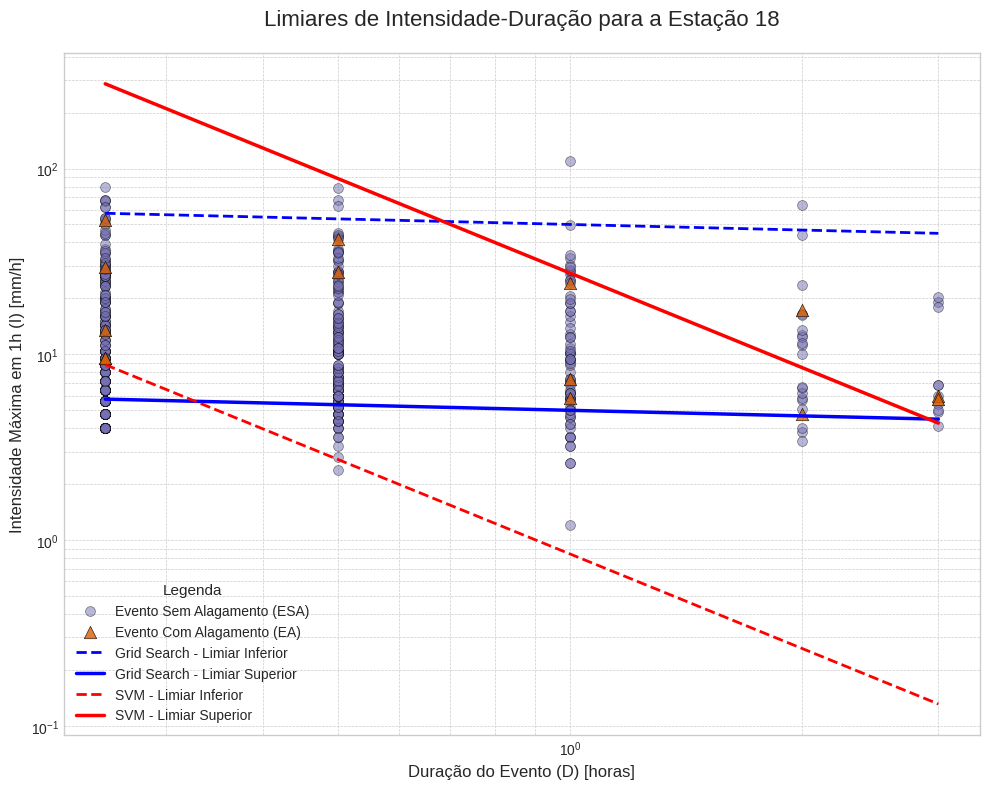

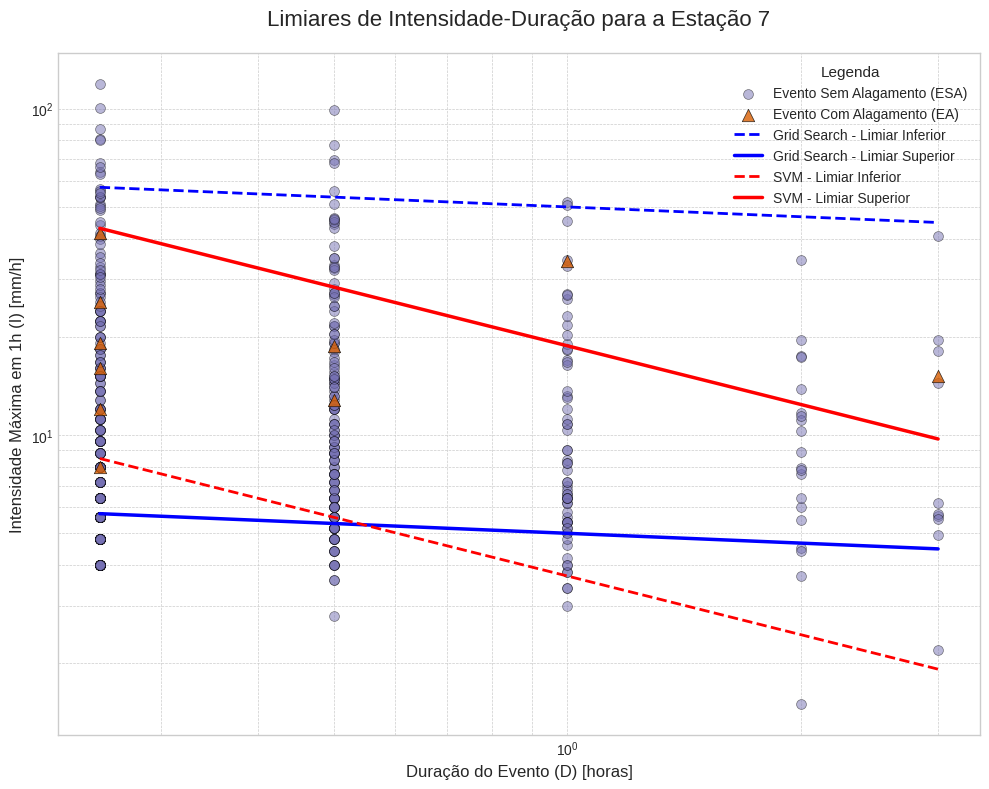

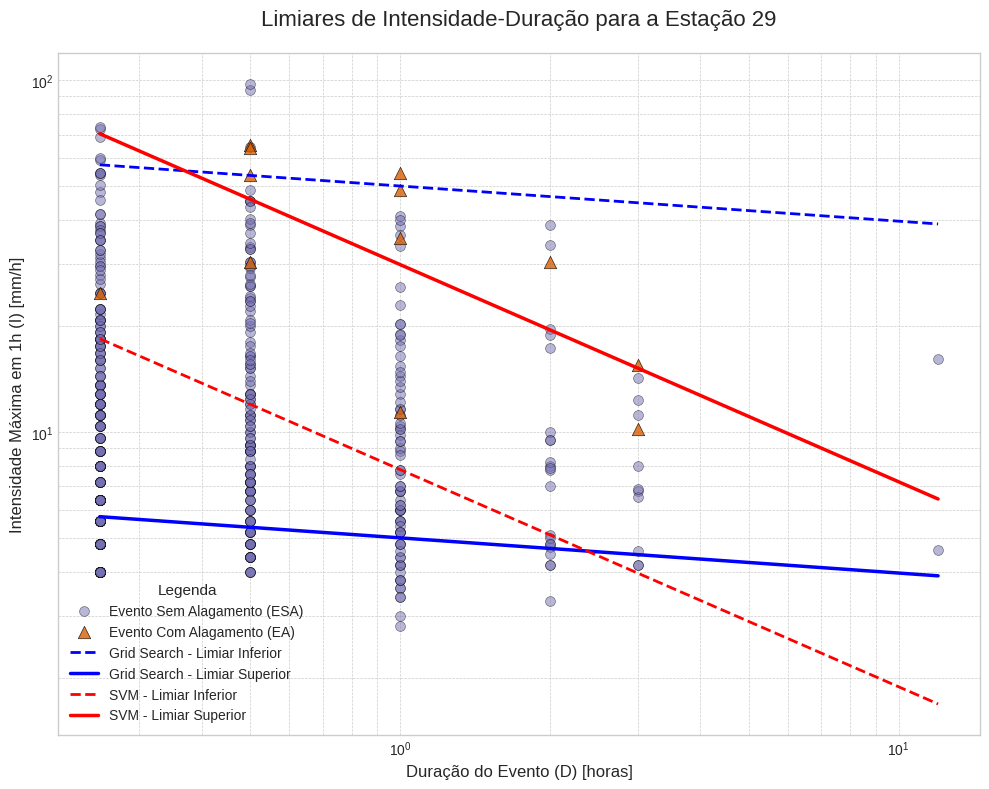

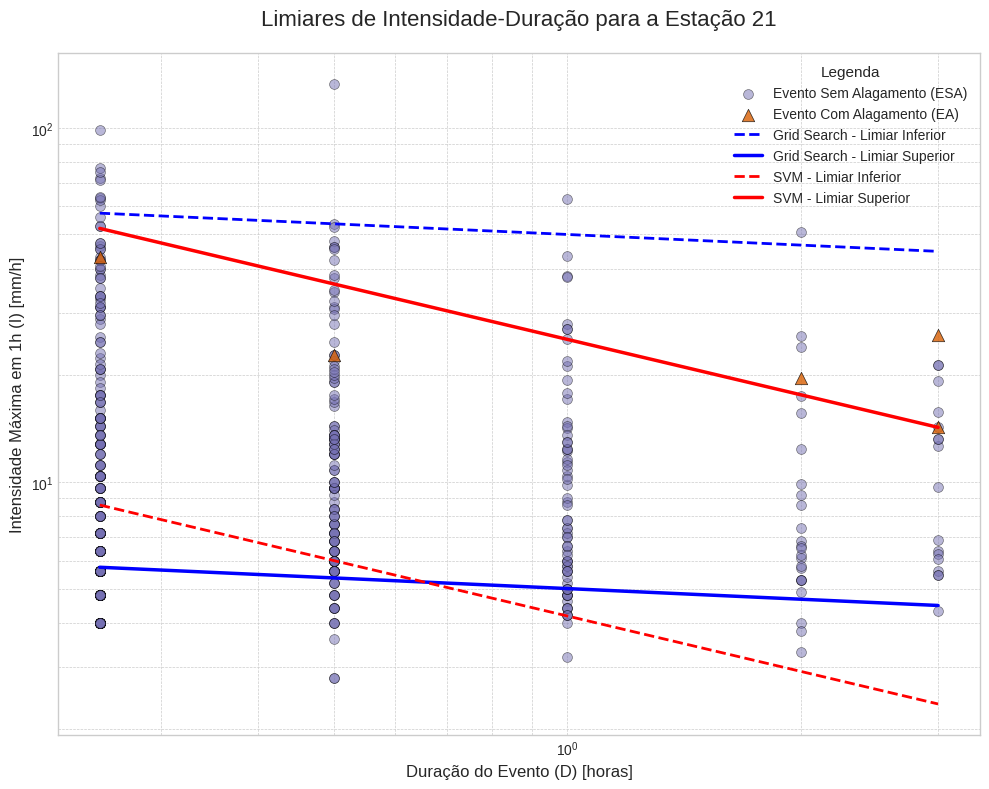

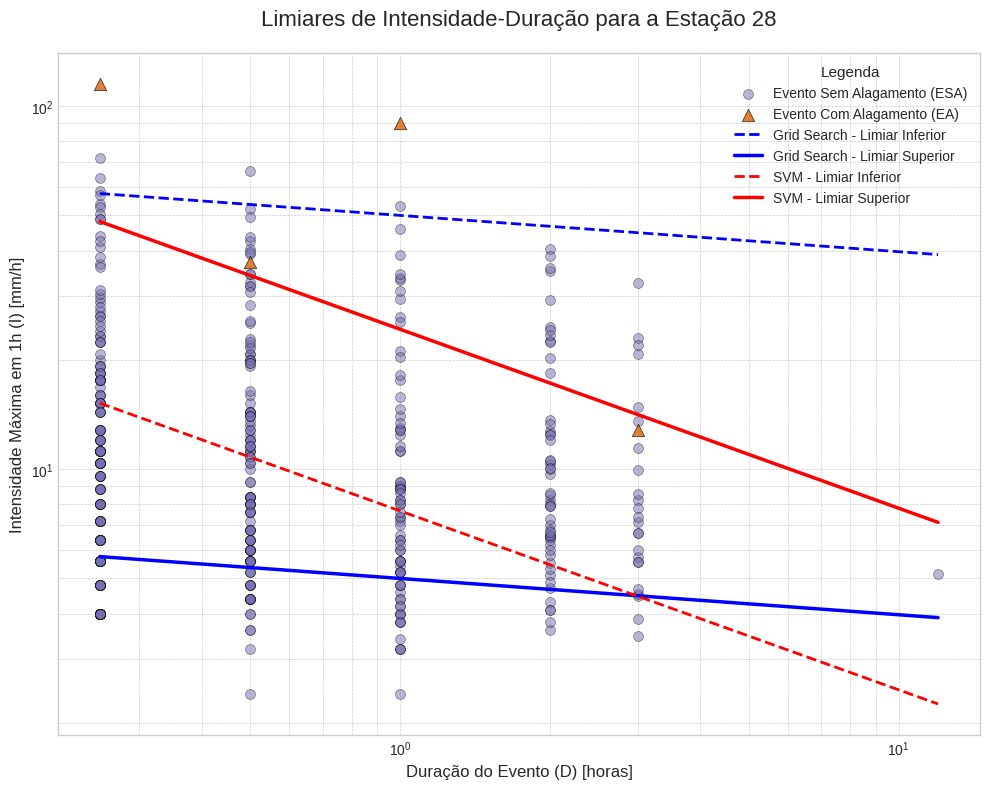

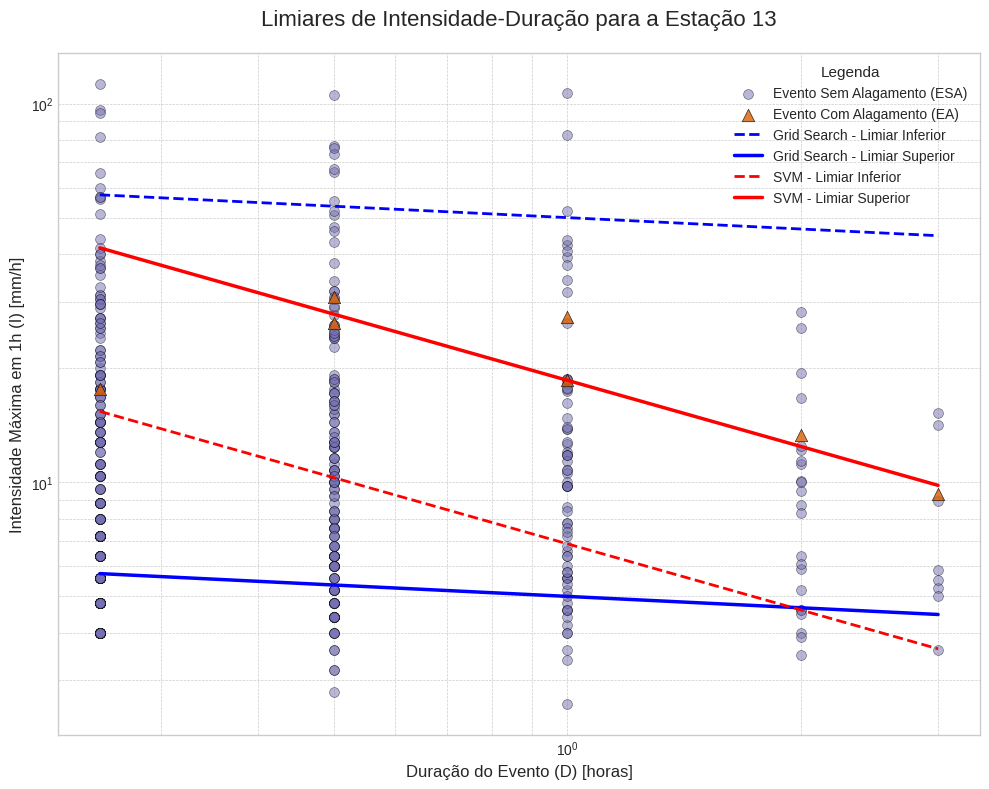

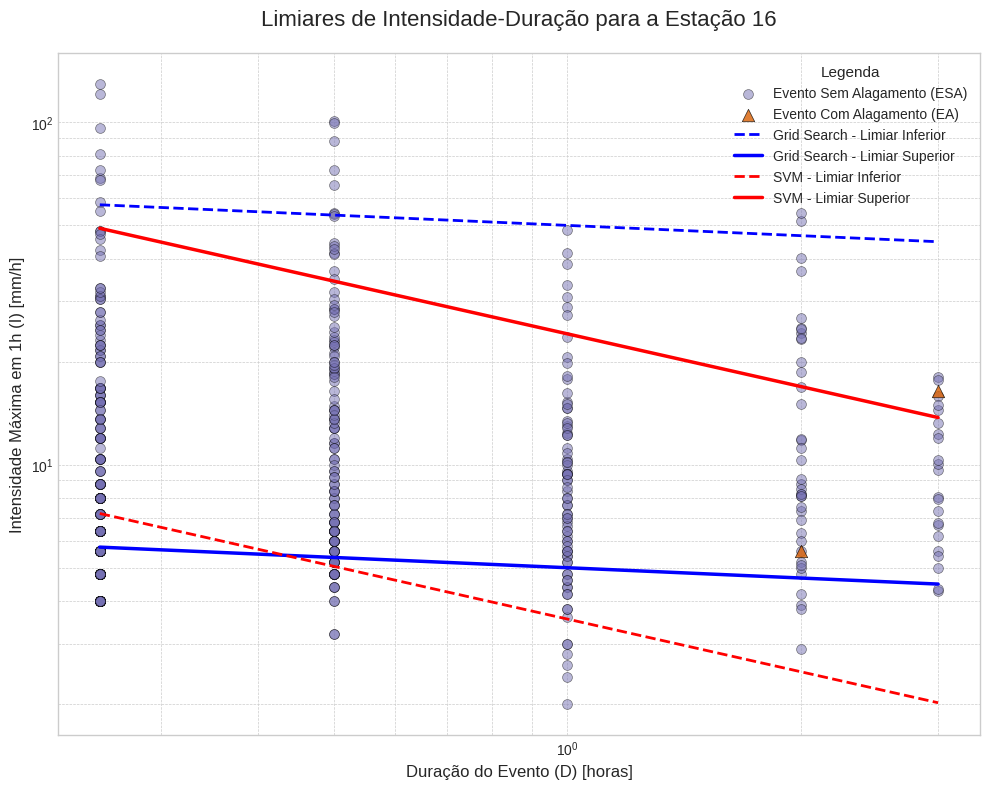

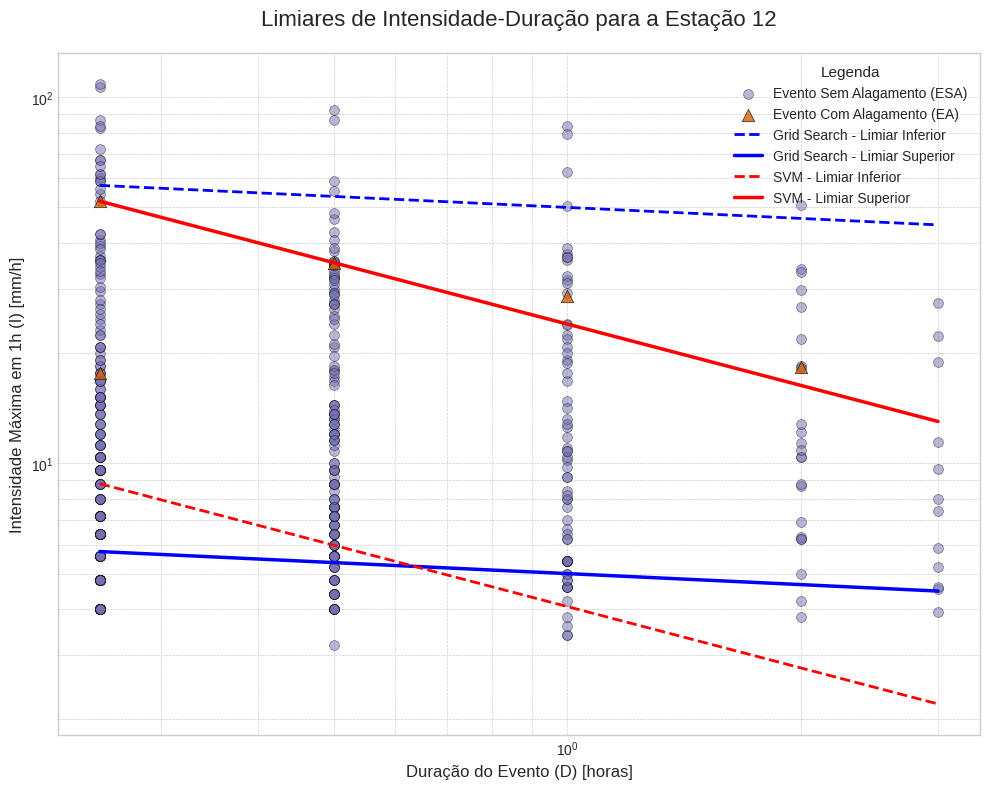

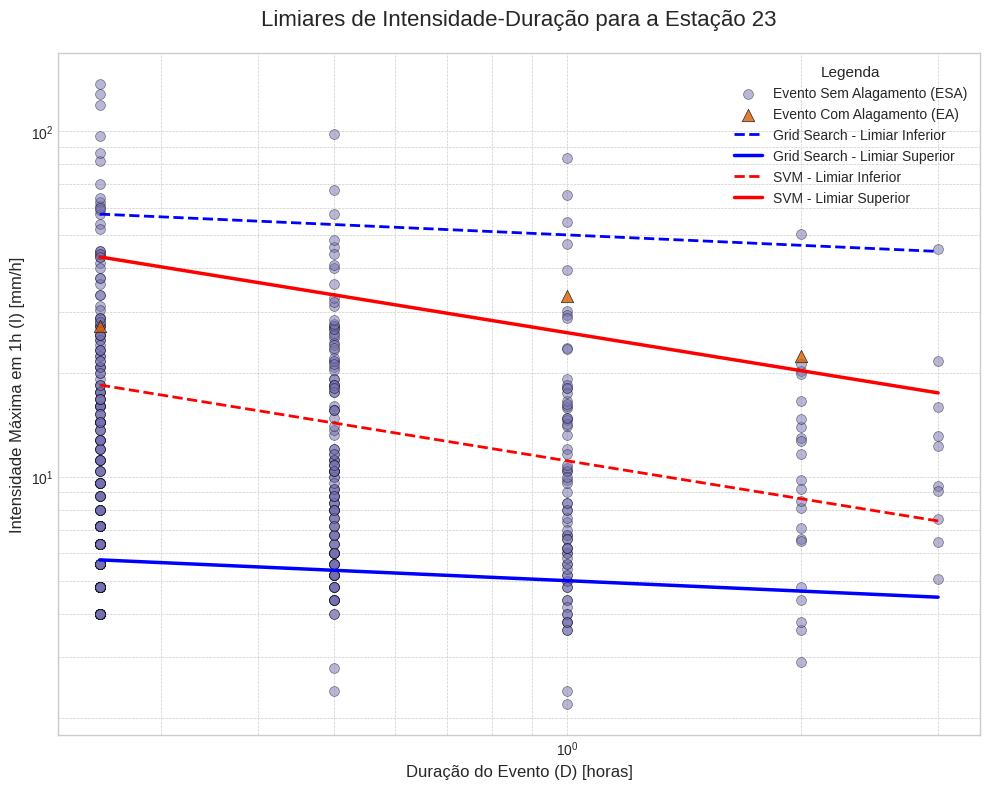

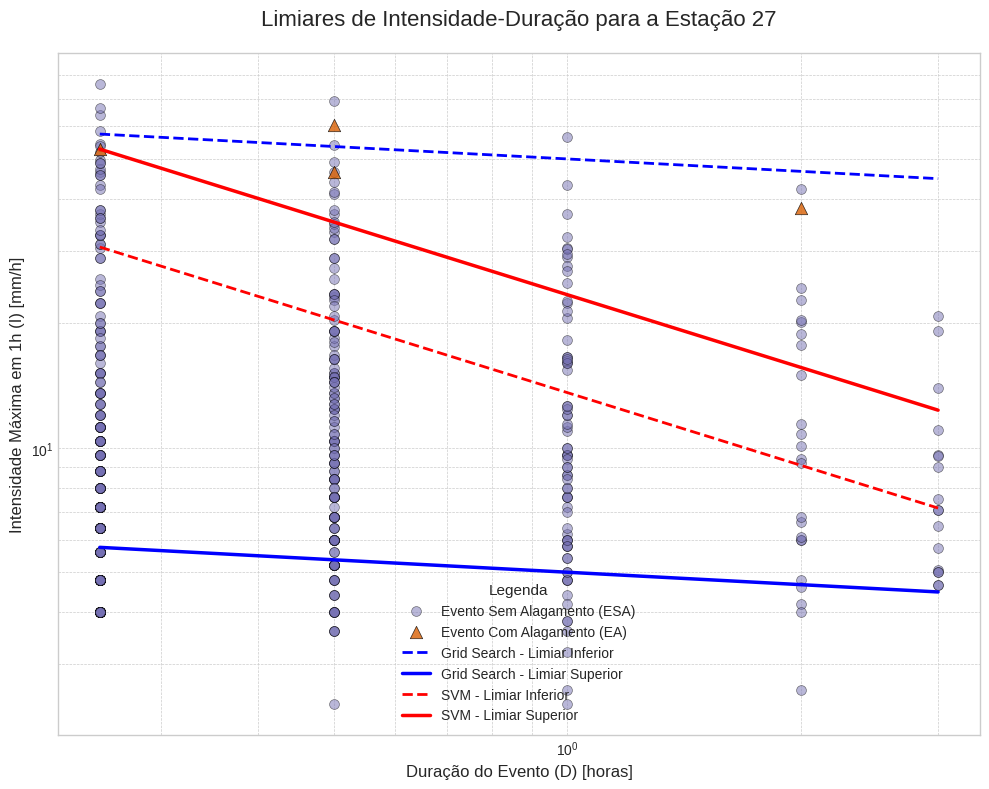

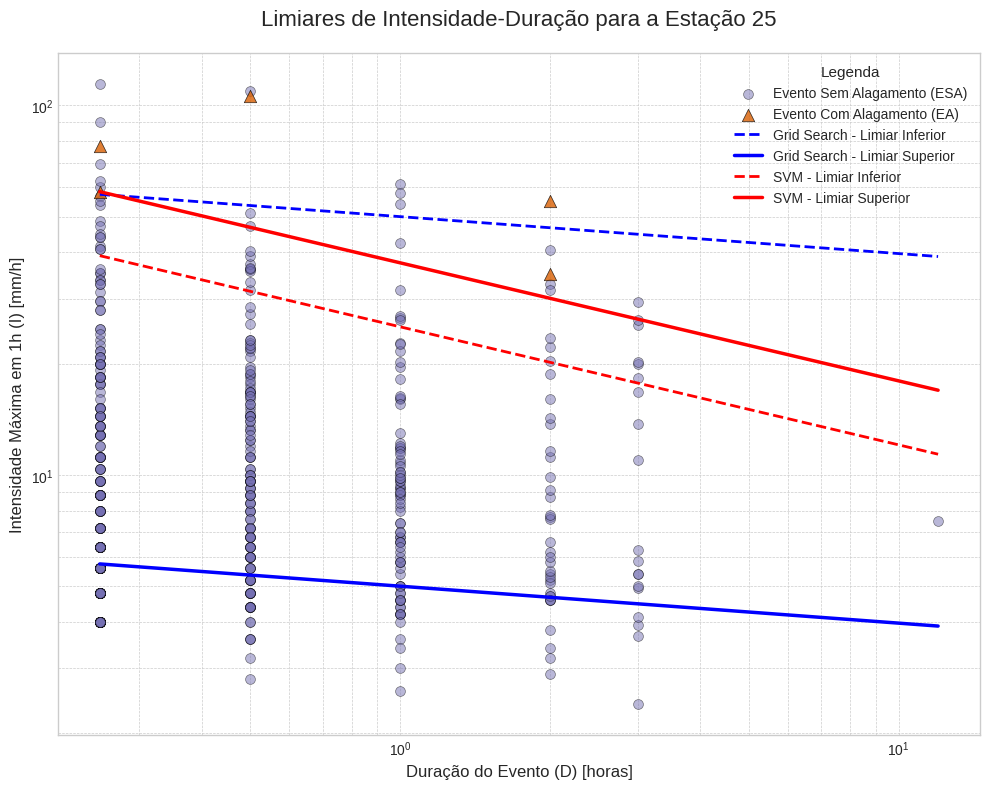

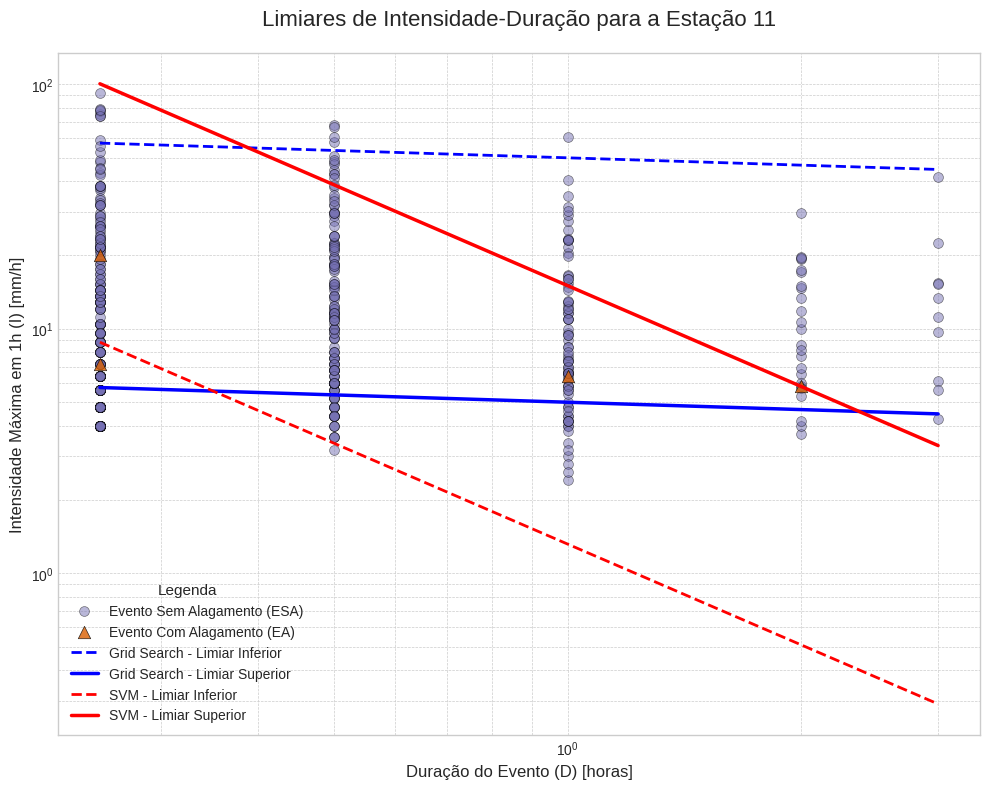

/tmp/ipykernel_2341923/3801914837.py:58: RuntimeWarning: overflow encountered in power
  i_inf_svm = params['a_inf_svm'] * (d_range ** -params['b_inf_svm'])
/tmp/ipykernel_2341923/3801914837.py:58: RuntimeWarning: invalid value encountered in multiply
  i_inf_svm = params['a_inf_svm'] * (d_range ** -params['b_inf_svm'])
/tmp/ipykernel_2341923/3801914837.py:61: RuntimeWarning: overflow encountered in power
  i_sup_svm = params['a_sup_svm'] * (d_range ** -params['b_sup_svm'])
/tmp/ipykernel_2341923/3801914837.py:61: RuntimeWarning: invalid value encountered in multiply
  i_sup_svm = params['a_sup_svm'] * (d_range ** -params['b_sup_svm'])


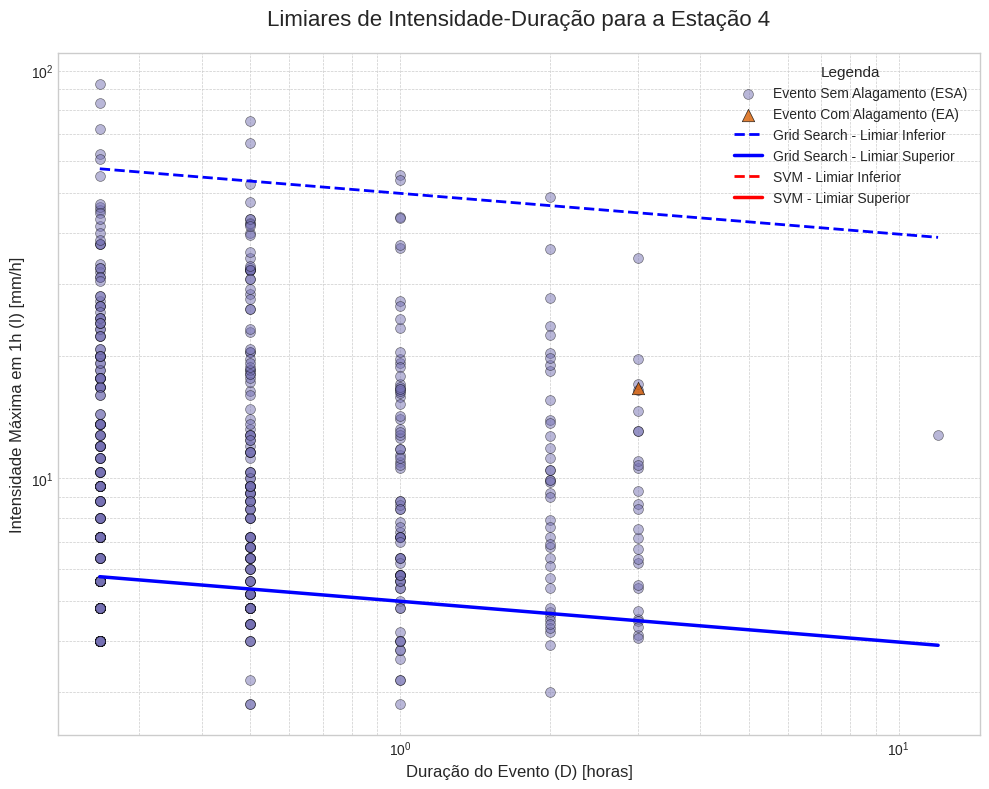

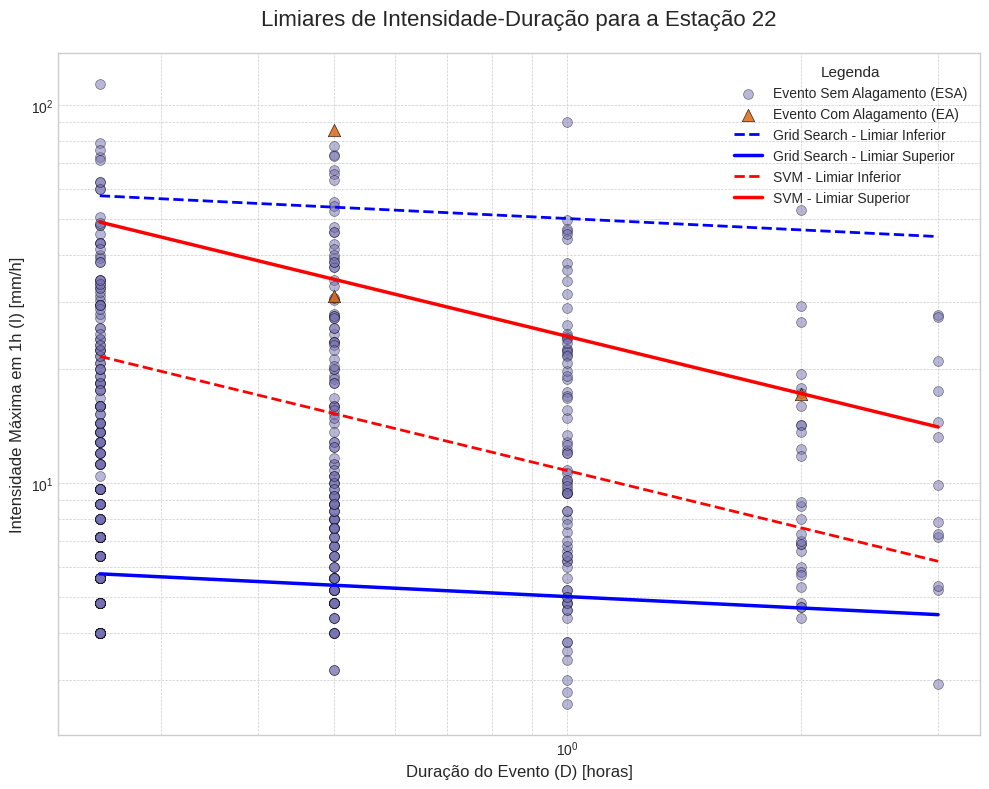

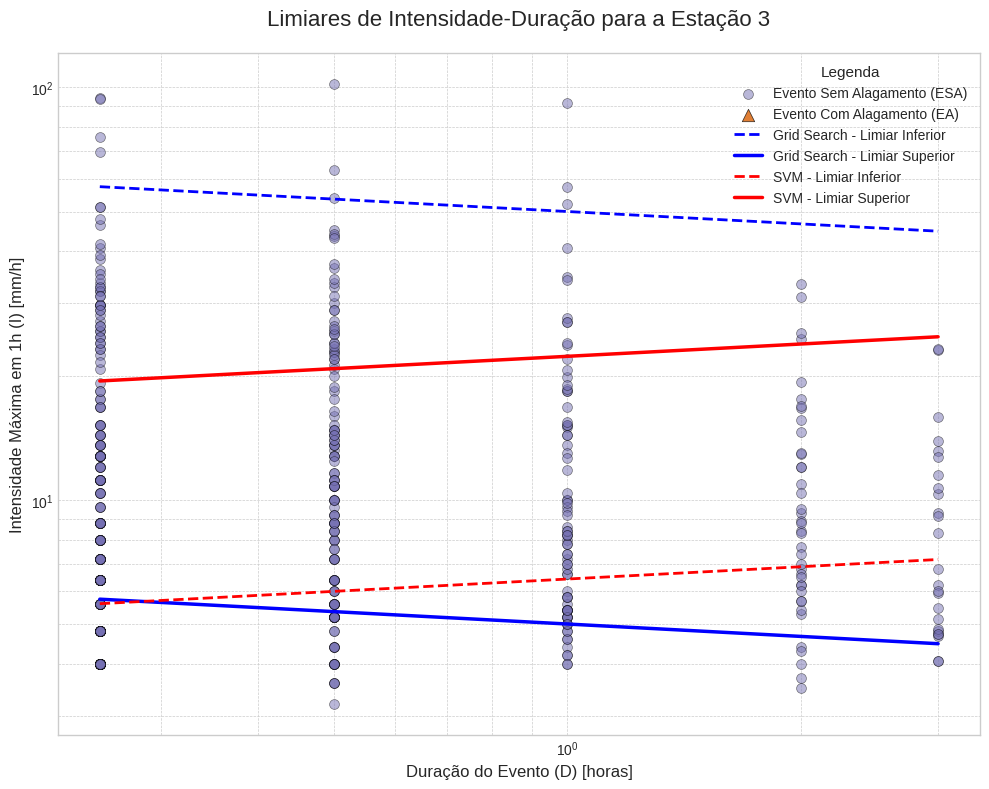

Estação 10 não possui resultados de limiar para plotar (provavelmente por falta de dados).


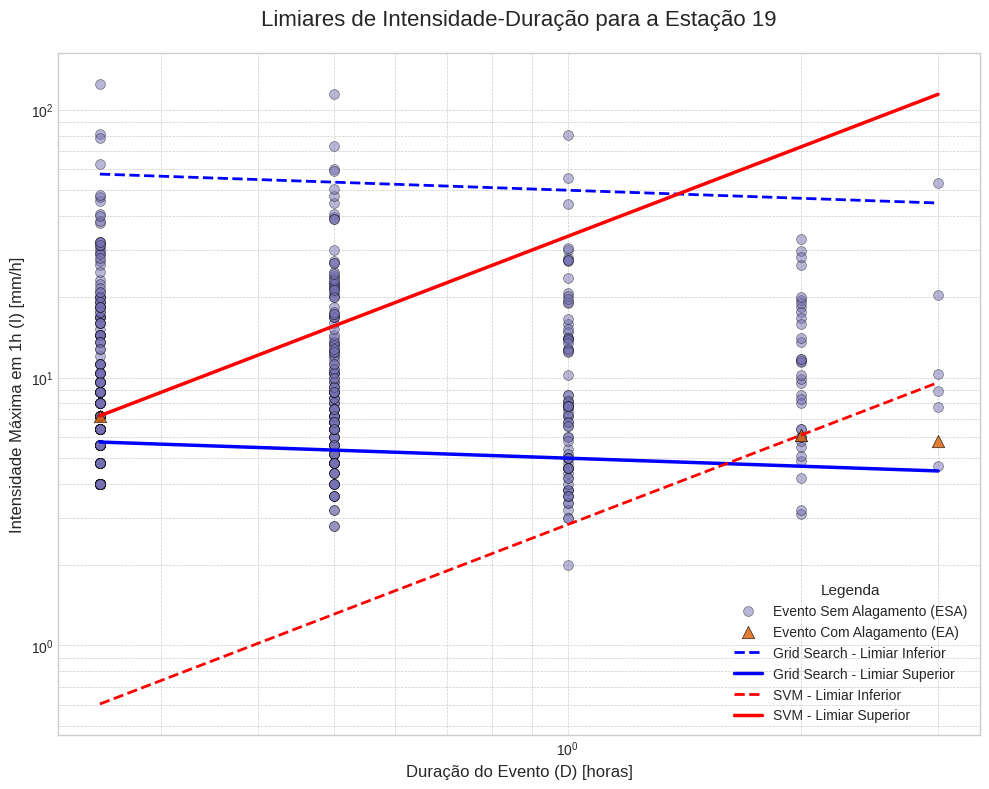

Estação 9 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 5 não possui resultados de limiar para plotar (provavelmente por falta de dados).


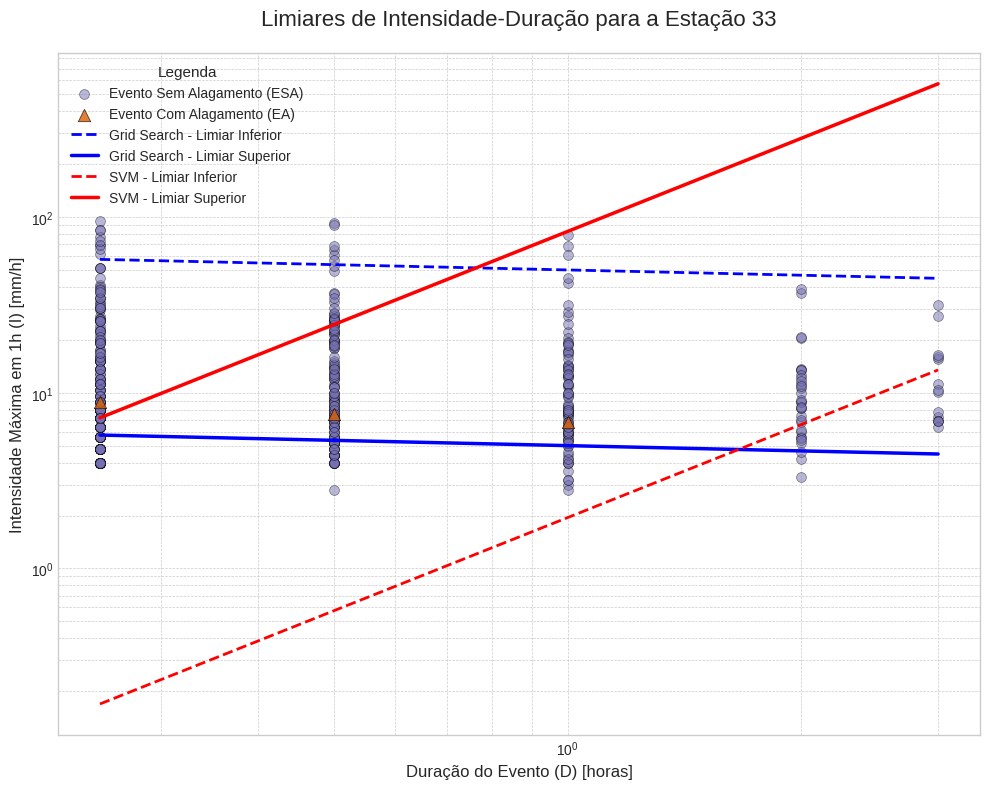

Estação 30 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 26 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 1 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 20 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 2 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 15 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 14 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 8 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 6 não possui resultados de limiar para plotar (provavelmente por falta de dados).
Estação 17 não possui resultados de limiar para plotar (provavelmente por falta de dados).


In [55]:
# Seleciona as 3 estações com mais eventos de alagamento para visualização

TOP_N = 33
top_stations_to_plot = classification_summary.sort_values(by='EA', ascending=False).head(TOP_N).index

print("Gerando gráficos de limiar para as 3 estações com mais eventos de alagamento registrados...")
for station_id in top_stations_to_plot:
    if station_id in resultados_limiar_consolidado.index:
        plotar_grafico_limiar_comparativo(
            station_id,
            pontos_id_df,
            resultados_limiar_consolidado,
            sample=500,
            random_state=None
        )
    else:
        print(f"Estação {station_id} não possui resultados de limiar para plotar (provavelmente por falta de dados).")

### 18.3. Análise Espacial dos Parâmetros de Limiar

Para entender como os limiares de chuva variam geograficamente pela cidade, criamos mapas coropléticos (choropleth maps). Estes mapas colorem a área de influência de cada estação (Polígono de Thiessen) de acordo com os valores dos parâmetros `a` e `b` encontrados. Analisaremos os resultados do método **Grid Search**, que é mais diretamente interpretável em termos de taxas de detecção.

-   **Parâmetro `a`:** Relaciona-se com a magnitude da chuva. Valores mais altos de `a` indicam que a estação suporta chuvas de maior intensidade para uma mesma duração antes de gerar alagamentos.
-   **Parâmetro `b`:** Relaciona-se com a sensibilidade à duração. Valores mais altos de `b` indicam que a intensidade crítica diminui mais rapidamente com o aumento da duração do evento.

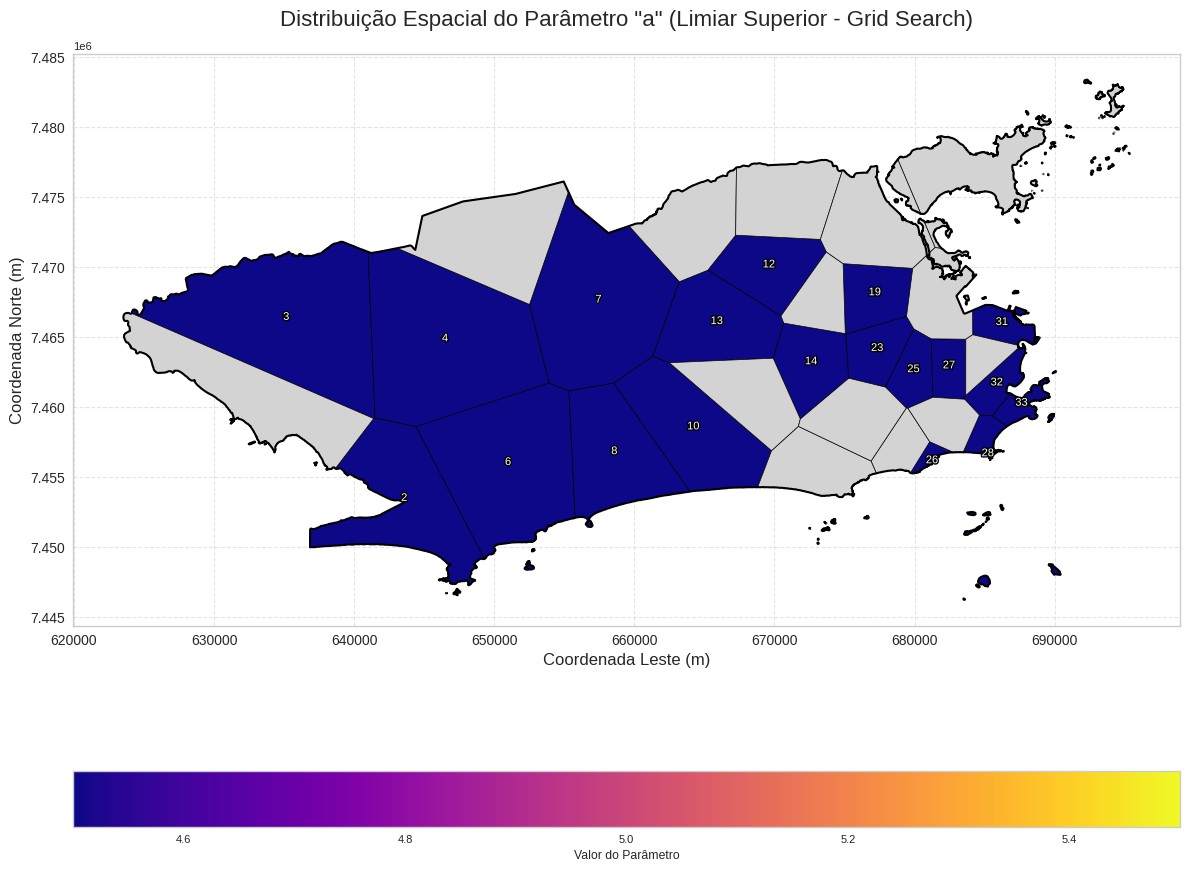

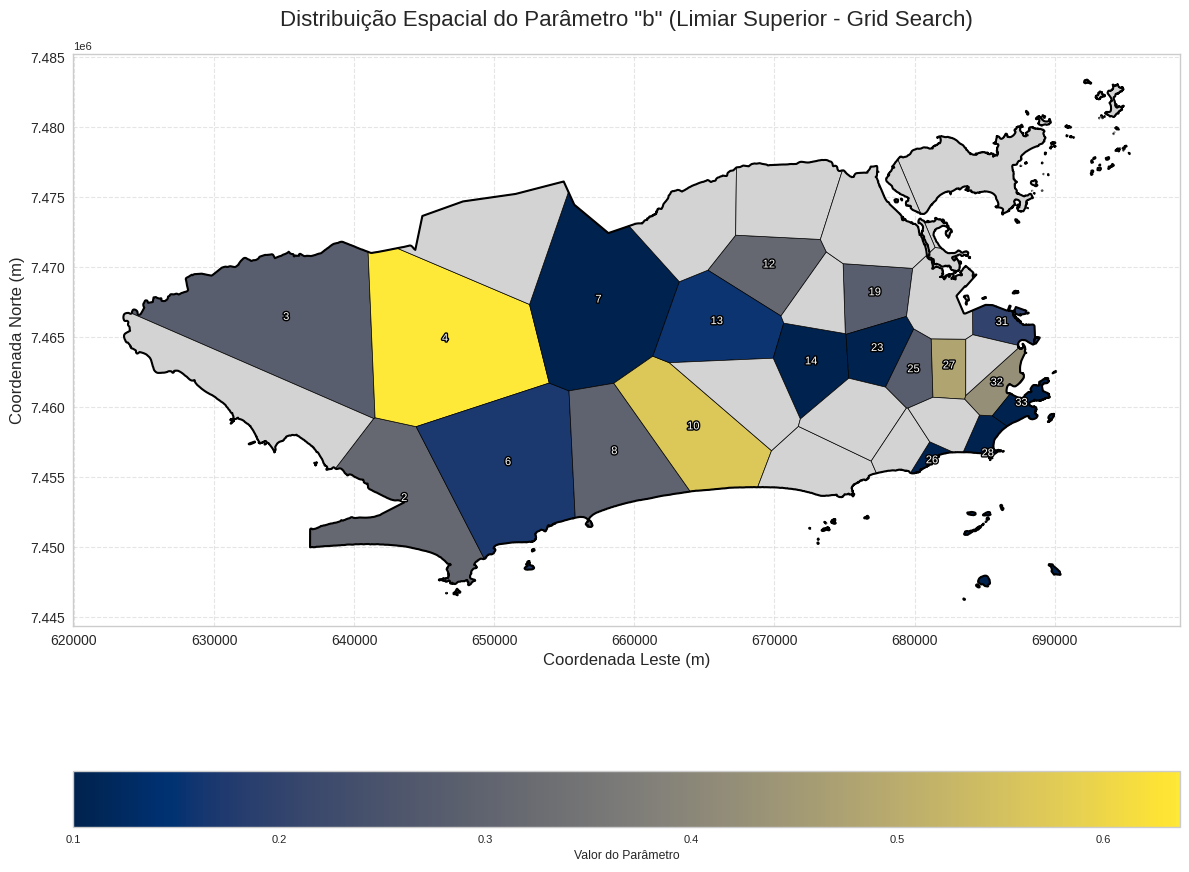

In [76]:
# Junta os resultados dos limiares ao GeoDataFrame dos polígonos de Thiessen
thiessen_com_limiares_gdf = thiessen_polygons_gdf.merge(
    resultados_limiar_consolidado,
    left_on='id_estacao',
    right_index=True,
    how='left'
)

# Função para criar mapas coropléticos
def plotar_mapa_parametros(gdf, column, title, cmap='viridis'):
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # Plota os polígonos com base no valor da coluna
    gdf.plot(column=column, ax=ax, legend=True,
             legend_kwds={'label': "Valor do Parâmetro", 'orientation': "horizontal"},
             cmap=cmap, missing_kwds={"color": "lightgrey", "label": "Sem Dados"},
             edgecolor='black', linewidth=0.5)
    
    # Adiciona o contorno da cidade
    city_boundary_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)
    
    # Adiciona rótulos com o ID da estação
    for idx, row in gdf.dropna(subset=[column]).iterrows():
        centroid = row.geometry.centroid
        ax.text(centroid.x, centroid.y, str(row['id_estacao']),
                fontsize=8, ha='center', color='white',
                path_effects=[plt.matplotlib.patheffects.withStroke(linewidth=2, foreground='black')])

    ax.set_title(title, fontsize=16, pad=20)
    ax.set_xlabel("Coordenada Leste (m)", fontsize=12)
    ax.set_ylabel("Coordenada Norte (m)", fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Gera os mapas para os parâmetros do limiar superior do método Grid Search
if not thiessen_com_limiares_gdf.empty:
    plotar_mapa_parametros(thiessen_com_limiares_gdf, 'a_sup_grid', 'Distribuição Espacial do Parâmetro "a" (Limiar Superior - Grid Search)', cmap='plasma')
    plotar_mapa_parametros(thiessen_com_limiares_gdf, 'b_sup_grid', 'Distribuição Espacial do Parâmetro "b" (Limiar Superior - Grid Search)', cmap='cividis')
else:
    print("Não foi possível gerar os mapas pois não há dados de limiares para associar aos polígonos.")
